# TouNum — Livrable 1 : Classification binaire *Photo* vs *Autre image*

**Projet** : chaîne automatique de *captioning* d'images pour TouNum (CESI — Data Science)
**Module** : filtre d'entrée du workflow — tri automatique des images numérisées
**Stack imposée** : Python · TensorFlow / Keras · scikit-learn · Pandas · ImageIO · NumPy · Matplotlib

---

### Sommaire

1. [Contexte métier et formalisation du problème](#1)
2. [Configuration de l'environnement](#2)
3. [Indexation et nettoyage des fichiers](#3)
4. [Analyse exploratoire (EDA)](#4)
5. [Prétraitement et mise en cache des images](#5)
6. [Stratégie d'échantillonnage : découpage Train / Validation / Test](#6)
7. [Pipeline de chargement à la volée et Data Augmentation](#7)
8. [Modèle 0 : référence naïve sur métadonnées (détection de biais)](#8)
9. [Modèle 1 : CNN construit *from scratch*](#9)
10. [Modèle 2 : Transfer Learning (EfficientNetB0) et fine-tuning](#10)
11. [Évaluation approfondie et pertinence statistique](#11)
12. [Industrialisation : sauvegarde et fonction `predict_is_photo`](#12)
13. [Conclusion, recul critique et pistes d'amélioration](#13)

<a id="1"></a>
## 1. Contexte métier et formalisation du problème

### 1.1 Le besoin de TouNum

TouNum numérise à la chaîne des fonds documentaires papier pour ses clients. L'entreprise veut ajouter à son offre un service de **légendage automatique** (*captioning*) : produire, pour chaque photographie numérisée, une phrase qui en décrit le contenu (« un homme fait du vélo dans une rue »). Ce service facilite ensuite l'indexation, la recherche et la valorisation des archives.

Deux obstacles précèdent le captioning proprement dit :

1. **La qualité variable des numérisations** (flou, bruit) : c'est l'objet du **Livrable 2** (débruitage et amélioration par filtres de convolution et auto-encodeurs).
2. **L'hétérogénéité des documents** : un lot numérisé ne contient pas que des photos. On y trouve des **textes scannés**, des **schémas**, des **croquis** et des **peintures**. Un modèle de captioning entraîné sur des photographies (jeux de type MS-COCO) produira des légendes absurdes sur une page de texte ou un plan technique.

**Ce premier livrable construit le filtre qui se place en tête du workflow** : il décide, pour chaque image, si elle doit poursuivre dans la chaîne de captioning.

### 1.2 Place du module dans le workflow global

```
                          ┌──────────────────────────────┐
   Images numérisées ───► │ LIVRABLE 1 : filtre binaire  │
   (lots clients)         │ « est-ce une photo ? »       │
                          └──────────────┬───────────────┘
                     P(photo) ≥ seuil    │       P(photo) < seuil
                   ┌─────────────────────┴──────────────────────┐
                   ▼                                            ▼
     ┌───────────────────────────┐                ┌───────────────────────────┐
     │ LIVRABLE 2 : débruitage   │                │ Hors périmètre captioning │
     │ (filtres de convolution / │                │ (archivage, OCR pour les  │
     │  auto-encodeur)           │                │  textes, tri manuel...)   │
     └─────────────┬─────────────┘                └───────────────────────────┘
                   ▼
     ┌───────────────────────────┐
     │ LIVRABLE 3 : captioning   │
     │ CNN (encodeur) + RNN      │──►  « Un chien court sur une plage »
     └───────────────────────────┘
```

### 1.3 Formalisation en apprentissage supervisé

- **Entrée** : une image couleur ou niveaux de gris, de taille et de format quelconques (JPEG, PNG).
- **Sortie** : la probabilité $\hat p = P(\text{photo} \mid \text{image}) \in [0, 1]$, puis la décision $\hat y = \mathbb{1}[\hat p \geq \tau]$ pour un seuil $\tau$.
- **Étiquettes** : $y = 1$ pour une **photo** (classe positive) ; $y = 0$ pour **toute autre image** (*Painting, Schematics, Sketch, Text*).
- **Données** : environ 41 000 images déjà classées par TouNum, réparties dans 5 dossiers (un par sous-catégorie).

C'est une **classification binaire supervisée** traitée par **réseaux de neurones convolutifs** (CNN), conformément au cahier des charges.

### 1.4 Niveaux d'exigence fixés par TouNum

| Niveau | Objectif | Difficulté attendue |
|---|---|---|
| **Minimum** | Distinguer une photo d'un **schéma** ou d'un **texte scanné** | Faible : statistiques d'image très différentes (fond blanc, traits fins, peu de couleurs) |
| **Idéal** | Distinguer une photo d'une **peinture** (et d'un croquis) | Élevée : une peinture réaliste est visuellement proche d'une photo |

Le cas **Photo vs Painting** fera donc l'objet d'une évaluation dédiée (section 11.4).

### 1.5 Coût métier des erreurs et choix des métriques

| Erreur | Signification | Conséquence pour TouNum |
|---|---|---|
| **Faux positif** (FP) | une non-photo est envoyée au captioning | légende absurde livrée au client (perte de crédibilité) et calcul GPU gaspillé |
| **Faux négatif** (FN) | une photo est écartée | la photo n'est pas légendée (perte de valeur, mais rattrapable par un contrôle manuel) |

La classe *Photo* ne représente qu'environ un quart des données. L'**accuracy** seule est donc trompeuse : un modèle qui répondrait toujours « autre » obtiendrait déjà environ 76 %. Nous suivrons donc :

- la **précision** (part de vraies photos parmi les images envoyées au captioning, liée aux FP) ;
- le **rappel** (part des photos effectivement détectées, lié aux FN) ;
- le **F1-score** (moyenne harmonique des deux) ;
- la **ROC-AUC** et la **PR-AUC**, indépendantes du seuil, qui mesurent la capacité de discrimination ;
- des **intervalles de confiance à 95 %** (bootstrap) et un **test de McNemar** pour comparer les modèles rigoureusement.

### 1.6 Contraintes de conception

- **Automatisation complète** : de la donnée brute (archives ZIP) à la décision, sans étape manuelle.
- **Reproductibilité** : graine aléatoire fixée, découpages sauvegardés, configuration centralisée.
- **Maintenabilité** : un seul point de configuration, des fonctions documentées, un module Python autonome (`tounum_photo_filter.py`) réutilisable par le Livrable 3.
- **Portabilité** : le notebook s'exécute sur **Google Colab (GPU)** comme sur un **poste local (CPU)**. Cette version a été exécutée intégralement sur un poste local **sans GPU** (Intel i7-8850H, 16 Go de RAM), ce qui a guidé certains choix de dimensionnement (taille d'image, mise en cache).
- **Reprise sur point de sauvegarde** : les étapes longues (cache d'images, extraction de caractéristiques, entraînements) enregistrent leur résultat sur disque. Si le résultat existe déjà, il est **rechargé au lieu d'être recalculé**. Le notebook se ré-exécute ainsi de bout en bout en une vingtaine de minutes, ce qui est indispensable pour la maintenance et pour la démonstration en soutenance.

> **Note sur cette exécution.** Les trois entraînements ont été réalisés sur ce poste le 01/10/2026 (112 minutes de calcul au total). Le notebook a ensuite été ré-exécuté intégralement, de la première à la dernière cellule : les cellules d'entraînement affichent donc « poids rechargés », et les courbes d'apprentissage sont tracées à partir des historiques enregistrés pendant l'entraînement. Tous les résultats d'évaluation sont recalculés à chaque exécution.

<a id="2"></a>
## 2. Configuration de l'environnement

Toute la configuration (chemins, hyperparamètres) est regroupée dans **une seule cellule**. Pour exécuter le notebook sur un nouveau jeu de données ou un autre environnement, c'est le seul endroit à modifier. C'est un prérequis de maintenabilité pour TouNum.

In [1]:
# ============================================================================
# 2.1  Configuration générale : UNIQUE endroit à modifier pour un autre environnement
# ============================================================================
import os, sys, platform

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/projet_A5'        # dossier persistant (modèles, résultats) - à adapter
    ZIP_DIR     = '/content/drive/MyDrive/Dataset projet'    # contient les archives "Dataset Livrable 1 - *.zip"
    DATA_DIR    = '/content/unzip_data'                      # extraction sur le disque local (rapide) de la VM
else:
    PROJECT_DIR = 'G:/projet_A5'
    ZIP_DIR     = os.path.join(PROJECT_DIR, 'OneDrive_2026-09-24', 'Dataset projet')
    DATA_DIR    = os.path.join(PROJECT_DIR, 'data', 'livrable_1')

WORK_DIR  = os.path.join(PROJECT_DIR, 'outputs_livrable1')   # tout ce que produit ce notebook
CACHE_DIR = os.path.join(WORK_DIR, 'cache')                  # images redimensionnées, features
MODEL_DIR = os.path.join(WORK_DIR, 'models')                 # modèles entraînés + configuration de production
FIG_DIR   = os.path.join(WORK_DIR, 'figures')                # figures exportées (pour la soutenance)
for d in (WORK_DIR, CACHE_DIR, MODEL_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Les poids pré-entraînés Keras sont téléchargés dans le projet (et non dans le profil utilisateur)
os.environ.setdefault('KERAS_HOME', os.path.join(PROJECT_DIR, '.keras'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'                     # masque les logs C++ verbeux de TensorFlow

CONFIG = {
    'seed': 42,
    'positive_class': 'Photo',               # nom du dossier de la classe positive (y = 1)
    'valid_ext': ('.jpg', '.jpeg', '.png'),  # extensions acceptées
    'min_side': 32,                          # une image plus petite (en px) est jugée inexploitable
    'draft_size': 320,                       # taille minimale de décodage JPEG (accélération, cf. §5)
    'img_size_cnn': 128,                     # résolution d'entrée du CNN from scratch
    'img_size_tl': 160,                      # résolution d'entrée du modèle de transfer learning
    'val_size': 0.15, 'test_size': 0.15,     # proportions du découpage (train = 70 %)
    'batch_size': 64,
    'epochs_cnn': 12,  'lr_cnn': 1e-3,       # modèle 1
    'epochs_head': 40, 'lr_head': 1e-3,      # modèle 2 (tête sur features gelées)
    'epochs_ft': 3,    'lr_ft': 1e-4,        # modèle 2b (fine-tuning partiel)
    'n_workers': min(12, os.cpu_count() or 4),
    'force_retrain': False,                  # True : réentraîne même si un modèle sauvegardé existe (cf. §9.3)
}
print(f"Environnement : {'Google Colab' if IN_COLAB else 'poste local'} | {platform.system()} | Python {platform.python_version()}")
print('DATA_DIR =', DATA_DIR)
print('WORK_DIR =', WORK_DIR)

Environnement : poste local | Windows | Python 3.13.2
DATA_DIR = G:/projet_A5\data\livrable_1
WORK_DIR = G:/projet_A5\outputs_livrable1


In [2]:
# ============================================================================
# 2.2  Récupération automatique des données (extraction des archives si besoin)
# ============================================================================
import glob, zipfile

def extract_datasets(zip_dir, data_dir, pattern='Dataset Livrable 1 - *.zip'):
    '''Décompresse chaque archive "Dataset Livrable 1 - <Catégorie>.zip" dans data_dir,
    sauf si la catégorie y est déjà présente (exécution idempotente).'''
    os.makedirs(data_dir, exist_ok=True)
    for zp in sorted(glob.glob(os.path.join(zip_dir, pattern))):
        category = os.path.basename(zp).split(' - ')[-1].replace('.zip', '')
        target = os.path.join(data_dir, category)
        if os.path.isdir(target) and os.listdir(target):
            print(f'[déjà extrait] {category}')
            continue
        print(f'[extraction]   {zp}')
        with zipfile.ZipFile(zp) as z:
            z.extractall(data_dir)

extract_datasets(ZIP_DIR, DATA_DIR)
print('Sous-dossiers :', sorted(os.listdir(DATA_DIR)))

[déjà extrait] Painting
[déjà extrait] Photo
[déjà extrait] Schematics
[déjà extrait] Sketch
[déjà extrait] Text
Sous-dossiers : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


In [3]:
# ============================================================================
# 2.3  Imports, graines aléatoires et matériel disponible
# ============================================================================
import io, json, time, hashlib, random, warnings
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import imageio
import imageio.v3 as iio
from PIL import Image, ImageFilter

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from scipy import stats

import tensorflow as tf
import keras
from keras import layers

Image.MAX_IMAGE_PIXELS = None                  # certaines peintures dépassent 89 Mpx (limite anti "bombe" de PIL)
warnings.filterwarnings('ignore', category=UserWarning)

SEED = CONFIG['seed']
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)              # fixe les graines Python, NumPy et TensorFlow

# Charte graphique commune à tout le notebook (une couleur fixe par catégorie)
CAT_COLORS = {'Photo': '#2a78d6', 'Painting': '#eb6834', 'Schematics': '#1baf7a',
              'Sketch': '#eda100', 'Text': '#e87ba4'}
BIN_COLORS = {'Photo': '#2a78d6', 'Autre': '#eb6834'}
MODEL_COLORS = {'M0 Métadonnées': '#8a8985', 'M1 CNN scratch': '#2a78d6',
                'M2 EffNet gelé': '#eb6834', 'M2b EffNet fine-tuné': '#1baf7a'}
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
                     'axes.titleweight': 'bold', 'font.size': 10})

def savefig(name):
    '''Enregistre la figure courante dans FIG_DIR (réutilisable pour la soutenance).'''
    plt.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=120, bbox_inches='tight')

print('Versions :')
for name, mod in [('numpy', np), ('pandas', pd), ('matplotlib', matplotlib), ('imageio', imageio),
                  ('scikit-learn', sklearn), ('tensorflow', tf), ('keras', keras)]:
    print(f'  {name:<13}{mod.__version__}')
gpus = tf.config.list_physical_devices('GPU')
DEVICE = 'GPU' if gpus else f'CPU ({os.cpu_count()} threads)'
print('GPU disponible :', gpus if gpus else 'aucun : exécution sur CPU', '| cœurs CPU :', os.cpu_count())

Versions :
  numpy        2.2.4
  pandas       2.2.3
  matplotlib   3.10.1
  imageio      2.38.0
  scikit-learn 1.7.2
  tensorflow   2.21.0
  keras        3.15.1
GPU disponible : aucun : exécution sur CPU | cœurs CPU : 12


<a id="3"></a>
## 3. Indexation et nettoyage des fichiers

Avant tout apprentissage, on construit un **index** (un `DataFrame` Pandas avec une ligne par fichier) qui sert de référence unique pour toute la suite. On n'itère plus jamais directement sur les dossiers. Cette approche :

- rend le traitement **traçable** (on sait pourquoi chaque fichier a été gardé ou exclu) ;
- permet un **découpage stratifié** reproductible ;
- s'adapte automatiquement à n'importe quel nouveau lot structuré en `DATA_DIR/<catégorie>/<fichiers>`.

**Contrôles appliqués à chaque fichier** :

1. **Extension** : seuls `.jpg`, `.jpeg` et `.png` sont conservés. Les dossiers contiennent des fichiers parasites (par exemple `desktop.ini`, créé par Windows).
2. **Signature binaire** (*magic number*, les premiers octets du fichier) : on vérifie que le contenu correspond réellement à une image, quelle que soit l'extension.
3. **Lisibilité de l'en-tête** : ouverture avec PIL, qui lit uniquement l'en-tête (rapide), pour récupérer format, dimensions et mode colorimétrique.
4. **Taille minimale** : une image de moins de 32 px de côté ne contient aucune information exploitable.

In [4]:
# ============================================================================
# 3.1  Construction de l'index brut
# ============================================================================
def build_index(data_dir):
    '''Parcourt data_dir/<catégorie>/<fichier> et renvoie un DataFrame (1 ligne par fichier).'''
    rows = []
    for category in sorted(os.listdir(data_dir)):
        cdir = os.path.join(data_dir, category)
        if not os.path.isdir(cdir):
            continue
        for fname in sorted(os.listdir(cdir)):
            path = os.path.join(cdir, fname)
            if os.path.isfile(path):
                rows.append({'path': path.replace('\\', '/'), 'category': category, 'filename': fname,
                             'ext': os.path.splitext(fname)[1].lower(), 'size_bytes': os.path.getsize(path)})
    return pd.DataFrame(rows)

t0 = time.time()
df_raw = build_index(DATA_DIR)
print(f'{len(df_raw):,} fichiers indexés en {time.time() - t0:.1f} s')
display(df_raw.head())
print('\nFichiers par dossier et par extension :')
display(pd.crosstab(df_raw['category'], df_raw['ext'], margins=True, margins_name='Total'))

41,401 fichiers indexés en 4.9 s


,path,category,filename,ext,size_bytes
0,G:/projet_A5/data/livrable_1/Painting/livrable...,Painting,livrable_1.ipynb,.ipynb,312
1,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00001.jpg,.jpg,167430
2,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00002.jpg,.jpg,28800
3,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00003.jpg,.jpg,139530
4,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00004.jpg,.jpg,115751



Fichiers par dossier et par extension :


ext,.ini,.ipynb,.jpg,.png,Total
category,,,,,
Painting,0,1,10000,0,10001
Photo,0,0,9993,0,9993
Schematics,1,0,10000,0,10001
Sketch,0,0,606,800,1406
Text,0,0,10000,0,10000
Total,1,1,40599,800,41401


In [5]:
# ============================================================================
# 3.2  Inspection de chaque fichier : signature binaire + en-tête image
# ============================================================================
MAGIC_NUMBERS = {b'\xff\xd8\xff': 'JPEG', b'\x89PNG\r\n\x1a\n': 'PNG', b'GIF8': 'GIF', b'BM': 'BMP', b'RIFF': 'WEBP'}

def inspect_file(path):
    '''Lit la signature et l'en-tête (sans décoder les pixels) : format, dimensions, mode.'''
    info = {'signature': 'INCONNUE', 'format': None, 'width': np.nan, 'height': np.nan,
            'mode': None, 'header_ok': False, 'error': None}
    try:
        with open(path, 'rb') as f:
            head = f.read(8)
        info['signature'] = next((v for k, v in MAGIC_NUMBERS.items() if head.startswith(k)), 'INCONNUE')
        with Image.open(path) as im:
            info.update(format=im.format, width=im.size[0], height=im.size[1], mode=im.mode, header_ok=True)
    except Exception as e:
        info['error'] = type(e).__name__
    return info

t0 = time.time()
with ThreadPoolExecutor(CONFIG['n_workers']) as ex:          # I/O : les threads suffisent
    infos = list(ex.map(inspect_file, df_raw['path']))
df_raw = pd.concat([df_raw, pd.DataFrame(infos)], axis=1)
df_raw['label'] = (df_raw['category'] == CONFIG['positive_class']).astype(int)
print(f'Inspection de {len(df_raw):,} fichiers en {time.time() - t0:.1f} s\n')

print('Signature binaire réelle vs extension :')
display(pd.crosstab([df_raw['category'], df_raw['ext']], df_raw['signature']))
mismatch = df_raw[(df_raw['ext'].isin(['.jpg', '.jpeg']) & (df_raw['signature'] != 'JPEG')) |
                  ((df_raw['ext'] == '.png') & (df_raw['signature'] != 'PNG'))]
print(f"Fichiers dont l'extension ne correspond pas au contenu : {len(mismatch)}")

Inspection de 41,401 fichiers en 53.5 s

Signature binaire réelle vs extension :


signature          BMP  GIF  INCONNUE   JPEG  PNG
category   ext                                   
Painting   .ipynb    0    0         1      0    0
           .jpg      1    1         0   9977   21
Photo      .jpg      0    0         0   9993    0
Schematics .ini      0    0         1      0    0
           .jpg      0    0         0  10000    0
Sketch     .jpg      0    0         0    606    0
           .png      0    0         0      0  800
Text       .jpg      0    0         0  10000    0

Fichiers dont l'extension ne correspond pas au contenu : 23


In [6]:
# ============================================================================
# 3.3  Règles de nettoyage (chaque exclusion est motivée et tracée)
# ============================================================================
df_raw['min_side'] = df_raw[['width', 'height']].min(axis=1)
reason = pd.Series(pd.NA, index=df_raw.index, dtype='object')
reason[~df_raw['ext'].isin(CONFIG['valid_ext'])] = 'extension non image'
reason[reason.isna() & ~df_raw['header_ok']] = 'en-tête illisible'
reason[reason.isna() & (df_raw['min_side'] < CONFIG['min_side'])] = f"trop petite (< {CONFIG['min_side']} px)"
df_raw['exclusion'] = reason

print('Exclusions :')
display(df_raw.groupby(['exclusion', 'category'], dropna=True).size().rename('n').to_frame())
print('Exemples de fichiers exclus :')
display(df_raw.loc[df_raw['exclusion'].notna(), ['category', 'filename', 'ext', 'signature', 'width', 'height', 'exclusion']].head(15))

df = df_raw[df_raw['exclusion'].isna()].reset_index(drop=True)
print(f'Images conservées après nettoyage : {len(df):,} / {len(df_raw):,}')

Exclusions :


n
exclusion             category       
extension non image   Painting      1
                      Schematics    1
trop petite (< 32 px) Schematics  662

Exemples de fichiers exclus :


,category,filename,ext,signature,width,height,exclusion
0,Painting,livrable_1.ipynb,.ipynb,INCONNUE,NaN,NaN,extension non image
19994,Schematics,desktop.ini,.ini,INCONNUE,NaN,NaN,extension non image
19996,Schematics,schematics_00002.jpg,.jpg,JPEG,14.0,35.0,trop petite (< 32 px)
20028,Schematics,schematics_00034.jpg,.jpg,JPEG,14.0,3.0,trop petite (< 32 px)
20037,Schematics,schematics_00043.jpg,.jpg,JPEG,21.0,36.0,trop petite (< 32 px)
20039,Schematics,schematics_00045.jpg,.jpg,JPEG,3.0,3.0,trop petite (< 32 px)
20043,Schematics,schematics_00049.jpg,.jpg,JPEG,21.0,18.0,trop petite (< 32 px)
20044,Schematics,schematics_00050.jpg,.jpg,JPEG,1.0,64.0,trop petite (< 32 px)
20051,Schematics,schematics_00057.jpg,.jpg,JPEG,6.0,36.0,trop petite (< 32 px)
20074,Schematics,schematics_00080.jpg,.jpg,JPEG,50.0,3.0,trop petite (< 32 px)


Images conservées après nettoyage : 40,737 / 41,401


**Lecture** :

- **2 fichiers parasites** (`desktop.ini`, généré par Windows, et un notebook `.ipynb` égaré dans le dossier *Painting*) sont écartés par le contrôle d'extension.
- **662 « schémas » font moins de 32 px** de côté (jusqu'à 1×64 px) : ce sont des icônes ou des fragments extraits de documents, qui ne contiennent aucune information exploitable. Environ 6,6 % de la catégorie *Schematics* est concerné, ce qui montre qu'**un jeu de données client n'est jamais propre**.
- **23 fichiers `.jpg` du dossier *Painting* sont en réalité des PNG, un GIF et un BMP**. On ne peut donc pas faire confiance aux extensions : notre chargement lit le contenu réel du fichier (PIL détecte le format par la signature binaire) et reste robuste.

<a id="4"></a>
## 4. Analyse exploratoire (EDA)

L'objectif est de comprendre les données **avant** de modéliser : l'équilibre des classes, l'hétérogénéité des formats, et les éventuels **biais** qu'un réseau de neurones pourrait exploiter à tort.

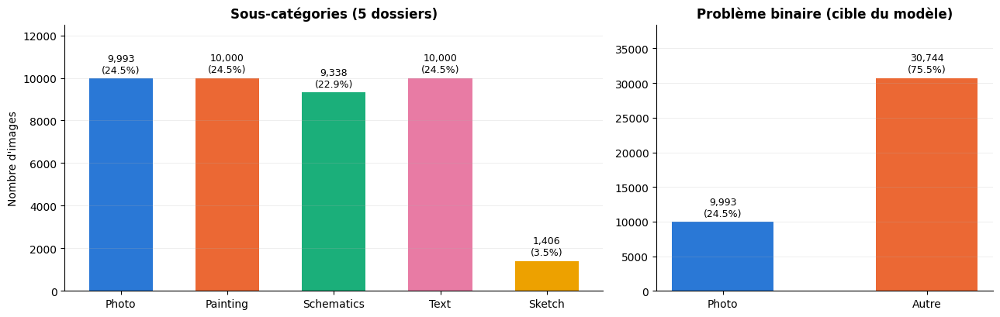

Déséquilibre : 3.08 images 'Autre' pour 1 'Photo'. Un classifieur trivial prédisant toujours 'Autre' aurait une accuracy de 75.5%.


In [7]:
# ============================================================================
# 4.1  Répartition des classes
# ============================================================================
counts = df['category'].value_counts().reindex(['Photo', 'Painting', 'Schematics', 'Text', 'Sketch'])
bin_counts = df['label'].map({1: 'Photo', 0: 'Autre'}).value_counts().reindex(['Photo', 'Autre'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=[CAT_COLORS[c] for c in counts.index], width=0.6)
ax.bar_label(bars, labels=[f'{v:,}\n({v / len(df):.1%})' for v in counts.values], padding=3, fontsize=9)
ax.set_title('Sous-catégories (5 dossiers)'); ax.set_ylabel("Nombre d'images"); ax.set_ylim(0, counts.max() * 1.25)
ax.grid(axis='x', visible=False)
ax = axes[1]
bars = ax.bar(bin_counts.index, bin_counts.values, color=[BIN_COLORS[c] for c in bin_counts.index], width=0.5)
ax.bar_label(bars, labels=[f'{v:,}\n({v / len(df):.1%})' for v in bin_counts.values], padding=3, fontsize=9)
ax.set_title('Problème binaire (cible du modèle)'); ax.set_ylim(0, bin_counts.max() * 1.25)
ax.grid(axis='x', visible=False)
plt.tight_layout(); savefig('eda_repartition_classes'); plt.show()

ratio = bin_counts['Autre'] / bin_counts['Photo']
print(f"Déséquilibre : {ratio:.2f} images 'Autre' pour 1 'Photo'. "
      f"Un classifieur trivial prédisant toujours 'Autre' aurait une accuracy de {bin_counts['Autre'] / len(df):.1%}.")

**Lecture** :

- La classe positive *Photo* représente environ **24 %** des images. Le problème est **déséquilibré** (environ 3 négatifs pour 1 positif). On compensera avec une **pondération des classes** dans la fonction de coût et des métriques adaptées (F1, AUC).
- La classe négative est **composite**. *Sketch* est sous-représentée (environ 3 %) : il faudra vérifier que le modèle ne la néglige pas (analyse par sous-catégorie, §11.3). Le découpage sera **stratifié sur la sous-catégorie**, et pas seulement sur l'étiquette binaire.

,n,largeur_med,hauteur_med,largeur_max,hauteur_max,ratio_med,mpx_med,ko_med,octets_par_px
category,,,,,,,,,
Photo,9993,640.0,480.0,640.0,640.0,1.33,0.27,152.89,0.58
Painting,10000,800.0,800.0,8169.0,8311.0,0.91,0.71,169.08,0.25
Schematics,9338,715.0,495.0,10200.0,9894.0,1.38,0.36,37.51,0.12
Text,10000,595.0,842.0,612.0,842.0,0.71,0.50,61.04,0.15
Sketch,1406,1111.0,1111.0,1111.0,1111.0,1.00,1.23,32.86,0.04


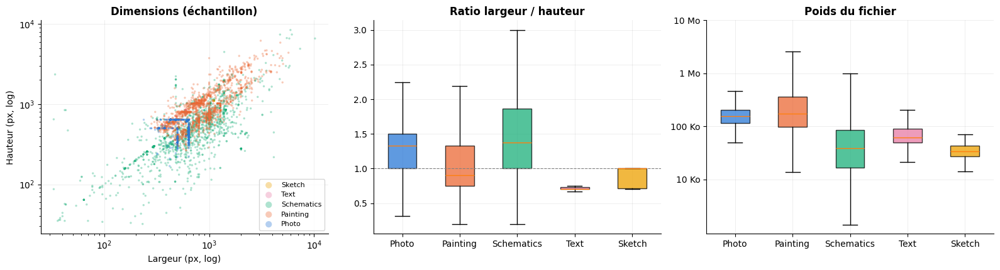

In [8]:
# ============================================================================
# 4.2  Dimensions, formats, modes colorimétriques et poids des fichiers
# ============================================================================
df['aspect'] = df['width'] / df['height']
df['megapixels'] = df['width'] * df['height'] / 1e6
df['bytes_per_px'] = df['size_bytes'] / (df['width'] * df['height'])
order = ['Photo', 'Painting', 'Schematics', 'Text', 'Sketch']

summary = df.groupby('category').agg(
    n=('path', 'size'),
    largeur_med=('width', 'median'), hauteur_med=('height', 'median'),
    largeur_max=('width', 'max'), hauteur_max=('height', 'max'),
    ratio_med=('aspect', 'median'), mpx_med=('megapixels', 'median'),
    ko_med=('size_bytes', lambda s: s.median() / 1024), octets_par_px=('bytes_per_px', 'median'),
).reindex(order).round(2)
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for cat in order[::-1]:                                   # Photo tracée en dernier (au premier plan)
    sub = df[df['category'] == cat].sample(min(1500, (df['category'] == cat).sum()), random_state=SEED)
    axes[0].scatter(sub['width'], sub['height'], s=6, alpha=0.35, color=CAT_COLORS[cat], label=cat, edgecolors='none')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Largeur (px, log)'); axes[0].set_ylabel('Hauteur (px, log)')
axes[0].set_title('Dimensions (échantillon)'); axes[0].legend(markerscale=3, fontsize=8)

data = [df.loc[df['category'] == c, 'aspect'].clip(0.2, 3) for c in order]
bp = axes[1].boxplot(data, tick_labels=order, showfliers=False, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
axes[1].axhline(1, color='gray', lw=0.8, ls='--'); axes[1].set_title('Ratio largeur / hauteur')

data = [np.log10(df.loc[df['category'] == c, 'size_bytes']) for c in order]
bp = axes[2].boxplot(data, tick_labels=order, showfliers=False, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
axes[2].set_yticks([4, 5, 6, 7], ['10 Ko', '100 Ko', '1 Mo', '10 Mo']); axes[2].set_title('Poids du fichier')
plt.tight_layout(); savefig('eda_dimensions'); plt.show()

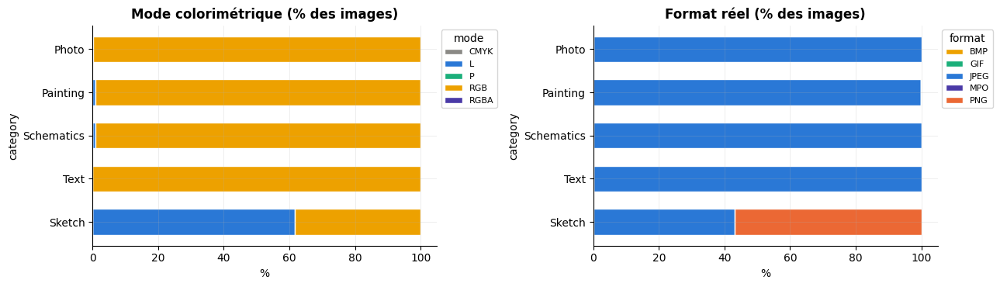

Effectifs par mode :


mode,CMYK,L,P,RGB,RGBA
category,,,,,
Photo,0,25,0,9968,0
Painting,1,82,5,9907,5
Schematics,0,74,0,9264,0
Text,0,0,0,10000,0
Sketch,0,868,0,538,0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
modes = pd.crosstab(df['category'], df['mode'], normalize='index').reindex(order) * 100
modes.plot(kind='barh', stacked=True, ax=axes[0], color=['#8a8985', '#2a78d6', '#1baf7a', '#eda100', '#4a3aa7'][:modes.shape[1]],
           width=0.6, edgecolor='white', linewidth=1)
axes[0].set_title('Mode colorimétrique (% des images)'); axes[0].set_xlabel('%'); axes[0].invert_yaxis()
axes[0].legend(title='mode', bbox_to_anchor=(1, 1), fontsize=8)
fmts = pd.crosstab(df['category'], df['format'], normalize='index').reindex(order) * 100
FMT_COLORS = {'JPEG': '#2a78d6', 'PNG': '#eb6834', 'GIF': '#1baf7a', 'BMP': '#eda100', 'MPO': '#4a3aa7'}
fmts.plot(kind='barh', stacked=True, ax=axes[1], color=[FMT_COLORS.get(f, '#8a8985') for f in fmts.columns],
          width=0.6, edgecolor='white', linewidth=1)
axes[1].set_title('Format réel (% des images)'); axes[1].set_xlabel('%'); axes[1].invert_yaxis()
axes[1].legend(title='format', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); savefig('eda_modes_formats'); plt.show()
print('Effectifs par mode :'); display(pd.crosstab(df['category'], df['mode']).reindex(order))

**Lecture** :

- **Formats hétérogènes** : les images vont de quelques dizaines de pixels à plus de 6 000 px de côté, avec des ratios variés (pages de texte en portrait A4, photos en paysage 4:3). Il faudra **normaliser la taille** à l'entrée du réseau (§5).
- **Modes mixtes** : on trouve du RGB, des niveaux de gris (`L`), et du PNG pour les croquis (parfois avec palette ou transparence). Le prétraitement doit **tout convertir en RGB 3 canaux**, avec composition sur fond blanc pour la transparence.
- **Point d'attention (biais de collecte)** : les photos ont presque toutes une taille bornée à 640 px (signature d'un corpus de type COCO), alors que les peintures sont souvent très grandes. Un modèle pourrait apprendre « petite image = photo » au lieu du contenu visuel. Ce risque de raccourci (*shortcut learning*) est quantifié en §8 avec un modèle volontairement naïf.

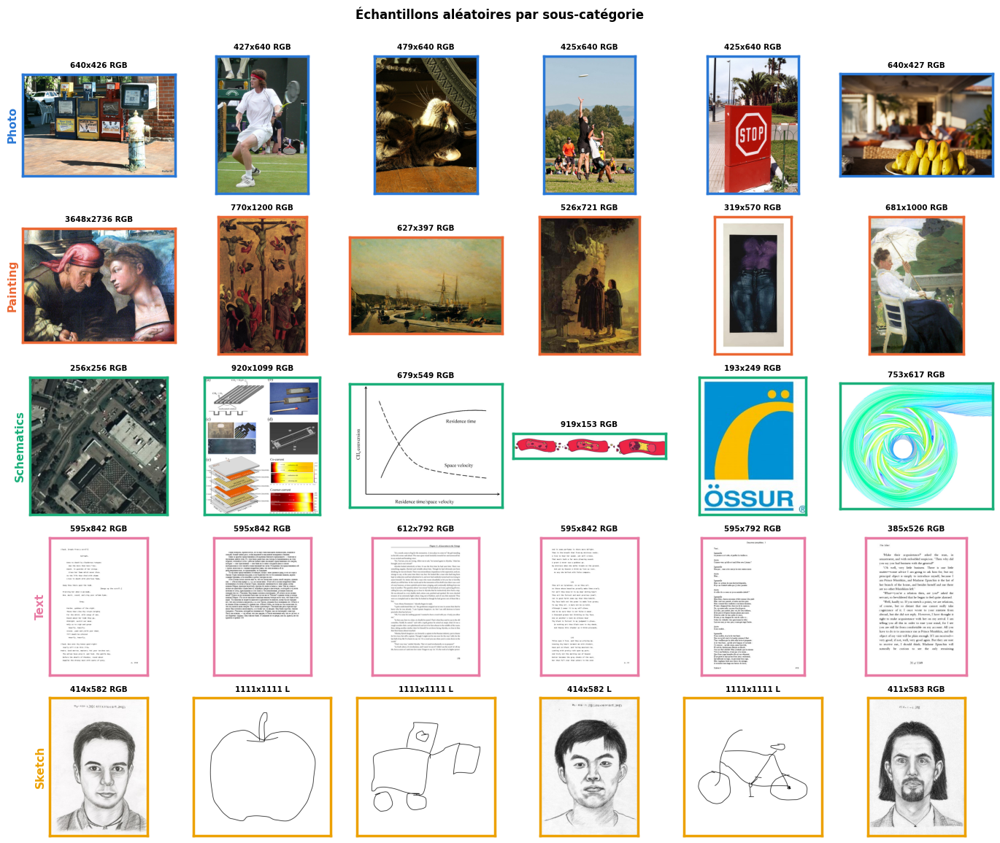

In [10]:
# ============================================================================
# 4.3  Échantillons par catégorie (chargement avec ImageIO)
# ============================================================================
n_per_cat = 6
fig, axes = plt.subplots(len(order), n_per_cat, figsize=(2.3 * n_per_cat, 2.3 * len(order)))
for r, cat in enumerate(order):
    sample = df[df['category'] == cat].sample(n_per_cat, random_state=SEED + 1)
    for c, (_, row) in enumerate(sample.iterrows()):
        img = iio.imread(row['path'])                   # lecture ImageIO (ndarray H x W [x C])
        ax = axes[r, c]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values():
            s.set_visible(True); s.set_color(CAT_COLORS[cat]); s.set_linewidth(2.5)
        ax.set_title(f"{int(row['width'])}x{int(row['height'])} {row['mode']}", fontsize=7.5)
        if c == 0:
            ax.set_ylabel(cat, fontsize=11, fontweight='bold', color=CAT_COLORS[cat])
plt.suptitle('Échantillons aléatoires par sous-catégorie', fontweight='bold', y=1.0)
plt.tight_layout(); savefig('eda_echantillons'); plt.show()

**Lecture** : les *Schematics* et *Text* ont des fonds blancs, des traits fins et une palette de couleurs réduite : ils sont faciles à séparer des photos. Les *Sketch* sont des dessins au trait, souvent en niveaux de gris. Les *Painting*, enfin, contiennent des scènes, des textures et des couleurs proches de celles d'une photo : ce sont elles qui feront la difficulté du problème.

⚠️ **Bruit d'étiquetage** : l'échantillon révèle déjà des cas ambigus. Le dossier *Schematics* contient une **vue aérienne** (visuellement, une photographie) et un **logo**. Le dossier *Painting* contient la **photo d'un tableau accroché au mur**. Ces images, étiquetées « autre », ressemblent à des photos : elles plafonneront les performances atteignables et devront être examinées lors de l'analyse d'erreurs (§11.6).

<a id="5"></a>
## 5. Prétraitement et mise en cache des images

### 5.1 Choix de prétraitement

Un réseau de neurones attend des tenseurs de **taille fixe**. Chaque image passe donc par la même chaîne :

| Étape | Choix | Justification |
|---|---|---|
| Décodage | PIL, avec `draft()` pour les JPEG | Le JPEG est stocké en blocs DCT : `draft` décode directement à 1/2, 1/4 ou 1/8 de la résolution. Le décodage des grandes peintures (jusqu'à 16 Mo) devient 5 à 10 fois plus rapide, sans perte utile puisqu'on réduit ensuite l'image. |
| Couleur | Conversion en **RGB** ; transparence composée sur **fond blanc** | Gère uniformément les modes L, P, RGBA et CMYK observés en §4. |
| Taille | Redimensionnement **bilinéaire** en carré (128 px pour le CNN, 160 px pour le transfer learning) | Compromis entre information et coût de calcul (entraînement sur CPU). Le rapport d'aspect n'est pas conservé : c'est volontaire, pour ne pas exposer le format de l'image comme indice (voir §8). |
| Valeurs | `uint8` [0, 255] en cache, normalisées **dans le modèle** | La normalisation (couche `Rescaling`, ou prétraitement interne d'EfficientNet) fait partie du modèle sauvegardé : aucun risque d'oubli en production. |

### 5.2 Pourquoi un cache ?

Décoder et redimensionner 40 000 images à **chaque epoch** coûterait plusieurs minutes par epoch. On les traite **une seule fois** et on les stocke sous forme de tableaux NumPy compacts (`.npy`, environ 2 Go en 128 px et 3 Go en 160 px), lus ensuite par *memory-mapping*. C'est la réponse concrète à la contrainte du sujet : ne pas saturer la RAM avec des milliers d'images en pleine résolution.

Sur ce poste, la construction du cache a pris **4,3 minutes** pour 40 737 images (environ 165 images/s avec 12 threads), sans aucun échec de décodage.

**Garantie de cohérence entraînement / production** : la même fonction `load_image_array` sert à construire le cache et, en production, dans `predict_is_photo` (§12). Un test d'égalité stricte le vérifie en §12.

La même passe calcule aussi, pour chaque image :

- une **empreinte MD5** du fichier et de la miniature, pour détecter les **doublons** ;
- quelques **statistiques de pixels** (luminosité, contraste, saturation, proportion de blanc, densité de contours) qui décrivent les différences visuelles entre catégories.

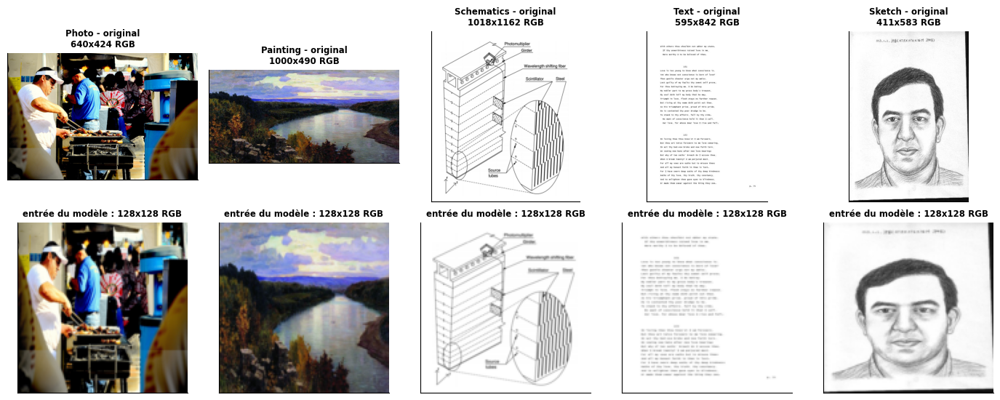

In [11]:
# ============================================================================
# 5.3  Fonctions de chargement (réutilisées telles quelles en production)
# ============================================================================
DRAFT_SIZE = CONFIG['draft_size']

def to_rgb(im):
    '''Convertit n'importe quel mode PIL (L, P, RGBA, CMYK...) en RGB ; la transparence est posée sur du blanc.'''
    if im.mode in ('RGBA', 'LA') or (im.mode == 'P' and 'transparency' in im.info):
        im = im.convert('RGBA')
        background = Image.new('RGBA', im.size, (255, 255, 255, 255))
        im = Image.alpha_composite(background, im)
    return im.convert('RGB')

def decode_image(src):
    '''Ouvre une image (chemin ou flux binaire) et la décode en RGB.
    Pour les JPEG, draft() décode directement à une résolution réduite (>= DRAFT_SIZE px).'''
    im = Image.open(src)
    if im.format == 'JPEG':
        im.draft('RGB', (DRAFT_SIZE, DRAFT_SIZE))
    return to_rgb(im)

def resize_array(im, size):
    '''Redimensionne une image PIL en carré size x size et renvoie un tableau uint8 (size, size, 3).'''
    return np.asarray(im.resize((size, size), Image.BILINEAR), dtype=np.uint8)

def load_image_array(src, size):
    '''Chaîne complète : fichier -> tableau uint8 (size, size, 3), prêt pour le modèle.'''
    return resize_array(decode_image(src), size)

def pixel_stats(arr):
    '''Descripteurs simples de l'apparence d'une image (tableau RGB uint8).'''
    x = arr.astype(np.float32) / 255.0
    gray = x.mean(axis=2)
    mx, mn = x.max(axis=2), x.min(axis=2)
    saturation = np.where(mx > 0, (mx - mn) / np.maximum(mx, 1e-6), 0)
    edges = np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()
    return {'brightness': gray.mean(), 'contrast': gray.std(), 'saturation': saturation.mean(),
            'white_ratio': (gray > 0.92).mean(), 'edge_density': edges}

# Démonstration sur une image de chaque catégorie
fig, axes = plt.subplots(2, 5, figsize=(14, 5.6))
for c, cat in enumerate(order):
    row = df[df['category'] == cat].iloc[3]
    original = iio.imread(row['path'])
    axes[0, c].imshow(original, cmap='gray' if original.ndim == 2 else None)
    axes[0, c].set_title(f"{cat} - original\n{original.shape[1]}x{original.shape[0]} {row['mode']}", fontsize=8.5)
    axes[1, c].imshow(load_image_array(row['path'], CONFIG['img_size_cnn']))
    axes[1, c].set_title(f"entrée du modèle : {CONFIG['img_size_cnn']}x{CONFIG['img_size_cnn']} RGB", fontsize=8.5)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); savefig('pretraitement_exemples'); plt.show()

In [12]:
# ============================================================================
# 5.4  Construction du cache (une seule passe sur les fichiers, parallélisée)
#      Idempotent : si le cache existe et correspond à l'index, il est simplement rechargé.
# ============================================================================
from numpy.lib.format import open_memmap

S1, S2 = CONFIG['img_size_cnn'], CONFIG['img_size_tl']
X1_PATH = os.path.join(CACHE_DIR, f'images_{S1}.npy')
X2_PATH = os.path.join(CACHE_DIR, f'images_{S2}.npy')
META_PATH = os.path.join(CACHE_DIR, 'cache_index.csv')

def process_file(path):
    '''Lit le fichier une seule fois : empreinte MD5, décodage, 2 résolutions, statistiques de pixels.'''
    try:
        with open(path, 'rb') as f:
            raw = f.read()
        im = decode_image(io.BytesIO(raw))
        a1, a2 = resize_array(im, S1), resize_array(im, S2)
        out = {'md5_file': hashlib.md5(raw).hexdigest(), 'md5_thumb': hashlib.md5(a1.tobytes()).hexdigest(),
               'decode_ok': True, 'decode_error': None, **pixel_stats(a1)}
        return out, a1, a2
    except Exception as e:
        return {'decode_ok': False, 'decode_error': f'{type(e).__name__}: {e}'[:120]}, None, None

cache_valid = False
if os.path.exists(META_PATH) and os.path.exists(X1_PATH) and os.path.exists(X2_PATH):
    meta = pd.read_csv(META_PATH)
    cache_valid = len(meta) == len(df) and (meta['path'].values == df['path'].values).all()

if cache_valid:
    built = time.strftime('%d/%m/%Y %H:%M', time.localtime(os.path.getmtime(META_PATH)))
    print(f'Cache existant et cohérent avec l\'index (construit le {built}) : rechargement sans recalcul.')
else:
    X1 = X2 = None; import gc; gc.collect()     # libère d'éventuels memmaps ouverts par une exécution précédente
    N = len(df)
    X1w = open_memmap(X1_PATH, mode='w+', dtype=np.uint8, shape=(N, S1, S1, 3))
    X2w = open_memmap(X2_PATH, mode='w+', dtype=np.uint8, shape=(N, S2, S2, 3))
    records, t0, paths, CHUNK = [], time.time(), df['path'].tolist(), 2000
    with ThreadPoolExecutor(CONFIG['n_workers']) as ex:
        for start in range(0, N, CHUNK):                     # blocs bornés : mémoire maîtrisée
            for j, (rec, a1, a2) in enumerate(ex.map(process_file, paths[start:start + CHUNK])):
                records.append(rec)
                if a1 is not None:
                    X1w[start + j], X2w[start + j] = a1, a2
            done = min(start + CHUNK, N)
            if done % 6000 == 0 or done == N:
                el = time.time() - t0
                print(f'  {done:>6,}/{N:,} images | {el / 60:4.1f} min | {done / el:5.0f} img/s')
    X1w.flush(); X2w.flush(); del X1w, X2w
    meta = pd.concat([df[['path']], pd.DataFrame(records)], axis=1)
    meta.to_csv(META_PATH, index=False)
    print(f'Cache construit en {(time.time() - t0) / 60:.1f} min')

# Reprise : un fichier en échec lors de la passe parallèle (par exemple mémoire saturée) est retraité seul.
# Seuls les fichiers réellement illisibles restent marqués en échec.
failed = np.flatnonzero(~meta['decode_ok'].values)
if len(failed):
    X1w, X2w = np.load(X1_PATH, mmap_mode='r+'), np.load(X2_PATH, mmap_mode='r+')
    meta['decode_error'] = meta['decode_error'].astype('object')
    recovered = 0
    for i in failed:
        rec, a1, a2 = process_file(meta.at[i, 'path'])
        if a1 is not None:
            X1w[i], X2w[i] = a1, a2
            for k, v in rec.items():
                meta.at[i, k] = v
            recovered += 1
    X1w.flush(); X2w.flush(); del X1w, X2w
    meta.to_csv(META_PATH, index=False)
    print(f'Reprise : {recovered}/{len(failed)} fichiers récupérés au second passage')

df = df.drop(columns=[c for c in meta.columns if c != 'path' and c in df.columns])   # ré-exécution sans doublon de colonnes
df = df.merge(meta, on='path', how='left')
df['cache_idx'] = np.arange(len(df))           # ligne correspondante dans les tableaux .npy
# Memory-mapping : les tableaux restent sur le disque, seuls les lots demandés sont lus.
# L'empreinte mémoire du notebook reste faible, même sur une machine peu dotée en RAM.
X1 = np.load(X1_PATH, mmap_mode='r')            # 128 px (CNN from scratch)
X2 = np.load(X2_PATH, mmap_mode='r')            # 160 px (transfer learning)
print(f'X1 {X1.shape} {X1.nbytes / 1e9:.2f} Go | X2 {X2.shape} {X2.nbytes / 1e9:.2f} Go (memory-mapping, hors RAM)')
n_fail = int((~df['decode_ok']).sum())
print(f'Échecs de décodage : {n_fail}')
if n_fail:
    display(df.loc[~df['decode_ok'], ['category', 'filename', 'decode_error']].head())

Cache existant et cohérent avec l'index (construit le 01/10/2026 09:22) : rechargement sans recalcul.
X1 (40737, 128, 128, 3) 2.00 Go | X2 (40737, 160, 160, 3) 3.13 Go (memory-mapping, hors RAM)
Échecs de décodage : 0


fichiers identiques octet par octet   :   743 images dans  308 groupes | dont groupes multi-catégories : 0
miniatures 128 px identiques          :   775 images dans  296 groupes | dont groupes multi-catégories : 1

Doublons intra-catégorie (copies surnuméraires) par catégorie :


,copies
category,
Schematics,472
Painting,4
Text,1


Images présentes dans plusieurs catégories (étiquette contradictoire) :


,groupes
category,
Schematics / Schematics / Text,1


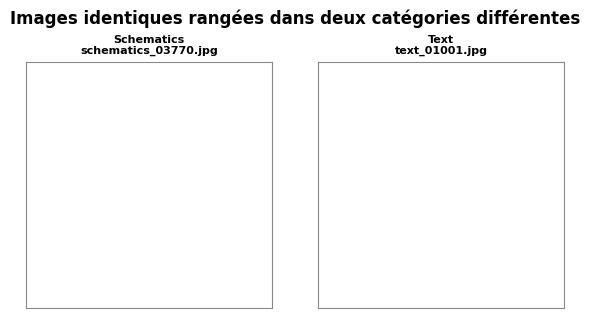

In [13]:
# ============================================================================
# 5.5  Doublons : fuite de données (train <-> test) et bruit d'étiquetage
# ============================================================================
ok = df['decode_ok']
for key, label in [('md5_file', 'fichiers identiques octet par octet'), ('md5_thumb', 'miniatures 128 px identiques')]:
    dup = df[ok & df.duplicated(key, keep=False)]
    groups = dup.groupby(key)['category'].agg(lambda s: tuple(sorted(set(s))))
    print(f"{label:<38}: {len(dup):>5} images dans {dup[key].nunique():>4} groupes "
          f"| dont groupes multi-catégories : {(groups.apply(len) > 1).sum()}")

# Groupe de doublons = même fichier OU même miniature
df['dup_key'] = df['md5_thumb'].where(ok, df['path'])
grp = df[ok].groupby('dup_key')['category'].agg(lambda s: set(s))
conflict_keys = set(grp[grp.apply(len) > 1].index)                       # même image, étiquettes différentes
df['is_conflict'] = df['dup_key'].isin(conflict_keys)
df['is_dup_copy'] = df.duplicated('dup_key', keep='first') & ~df['is_conflict']

print('\nDoublons intra-catégorie (copies surnuméraires) par catégorie :')
display(df[df['is_dup_copy']]['category'].value_counts().to_frame('copies'))
print('Images présentes dans plusieurs catégories (étiquette contradictoire) :')
display(df[df['is_conflict']].groupby('dup_key')['category'].agg(lambda s: ' / '.join(sorted(s))).value_counts().to_frame('groupes'))

if conflict_keys:
    keys = list(conflict_keys)[:4]
    fig, axes = plt.subplots(1, len(keys) * 2, figsize=(3 * len(keys) * 2, 3.2), squeeze=False)
    axes, k = axes.ravel(), 0
    for key in keys:
        for _, r in df[df['dup_key'] == key].drop_duplicates('category').head(2).iterrows():
            axes[k].imshow(X1[r['cache_idx']]); axes[k].set_title(f"{r['category']}\n{r['filename']}", fontsize=8)
            axes[k].set_xticks([]); axes[k].set_yticks([]); axes[k].grid(False)
            for sp in axes[k].spines.values():                      # cadre : l'image peut être entièrement blanche
                sp.set_visible(True); sp.set_color('#8a8985')
            k += 1
    plt.suptitle("Images identiques rangées dans deux catégories différentes", fontweight='bold'); plt.tight_layout(); plt.show()

In [14]:
# ============================================================================
# 5.6  Application des exclusions et bilan du nettoyage
# ============================================================================
df['exclusion'] = pd.NA
df.loc[~df['decode_ok'], 'exclusion'] = 'décodage impossible'
df.loc[df['exclusion'].isna() & df['is_conflict'], 'exclusion'] = 'doublon inter-catégories (étiquette ambiguë)'
df.loc[df['exclusion'].isna() & df['is_dup_copy'], 'exclusion'] = 'doublon intra-catégorie'

bilan = pd.concat([df_raw[df_raw['exclusion'].notna()][['category', 'exclusion']],
                   df[df['exclusion'].notna()][['category', 'exclusion']]])
display(pd.crosstab(bilan['exclusion'], bilan['category'], margins=True, margins_name='Total'))

df = df[df['exclusion'].isna()].reset_index(drop=True)
print(f'Jeu de données final : {len(df):,} images '
      f"({df['label'].sum():,} photos / {(1 - df['label']).sum():,} autres) sur {len(df_raw):,} fichiers bruts")

category,Painting,Schematics,Text,Total
exclusion,,,,
doublon inter-catégories (étiquette ambiguë),0,2,1,3
doublon intra-catégorie,4,472,1,477
extension non image,1,1,0,2
trop petite (< 32 px),0,662,0,662
Total,5,1137,2,1144


Jeu de données final : 40,257 images (9,993 photos / 30,264 autres) sur 41,401 fichiers bruts


**Lecture** :

- **477 copies surnuméraires** sont retirées, presque toutes dans *Schematics* (472) : le même schéma y figure plusieurs fois. Si on les laissait, une même image pourrait se trouver à la fois dans le jeu d'entraînement et dans le jeu de test : le score de test serait alors **surestimé** (fuite de données).
- **1 groupe en conflit d'étiquette** : une **page entièrement blanche**, présente à la fois dans *Schematics* et dans *Text*. Sans conséquence pour notre problème binaire (les deux sont « autre »), mais ces 3 images sont retirées par principe.
- Au total, **1 144 fichiers sur 41 401 (2,8 %)** sont écartés, chacun avec un motif tracé. La catégorie *Schematics* perd 11 % de ses images : c'est la moins propre du jeu de données.

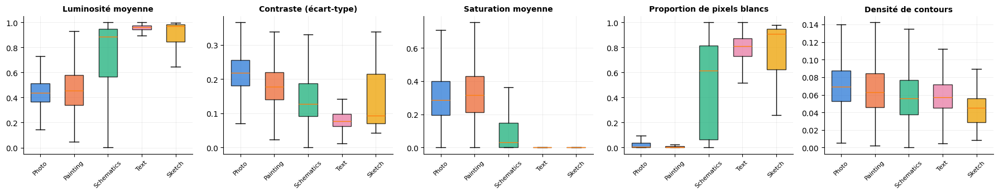

,brightness,contrast,saturation,white_ratio,edge_density
category,,,,,
Photo,0.436,0.218,0.286,0.008,0.069
Painting,0.456,0.178,0.317,0.000,0.063
Schematics,0.884,0.128,0.030,0.614,0.056
Text,0.959,0.077,0.000,0.812,0.057
Sketch,0.971,0.093,0.000,0.907,0.045


In [15]:
# ============================================================================
# 5.7  Ce que « voit » un réseau : statistiques de pixels par catégorie
# ============================================================================
feats = ['brightness', 'contrast', 'saturation', 'white_ratio', 'edge_density']
titles = ['Luminosité moyenne', 'Contraste (écart-type)', 'Saturation moyenne', 'Proportion de pixels blancs', 'Densité de contours']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, f, t in zip(axes, feats, titles):
    bp = ax.boxplot([df.loc[df['category'] == c, f] for c in order], tick_labels=order, showfliers=False,
                    patch_artist=True, widths=0.55)
    for patch, c in zip(bp['boxes'], order):
        patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
    ax.set_title(t, fontsize=10); ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); savefig('eda_stats_pixels'); plt.show()
display(df.groupby('category')[feats].median().reindex(order).round(3))

**Lecture** : *Text*, *Schematics* et *Sketch* se distinguent nettement des photos par une **forte proportion de blanc** et une **faible saturation**. Ce sont des indices de bas niveau que les premières couches convolutives captent facilement. Les *Painting* ont au contraire des distributions **proches de celles des photos** sur tous ces descripteurs. Leur séparation exige des indices plus fins : texture de la touche de pinceau, grain du capteur photo, cohérence de l'éclairage et de la perspective. C'est ce qui justifie des modèles convolutifs **profonds**, capables d'apprendre des motifs hiérarchiques plutôt que de simples statistiques globales.

<a id="6"></a>
## 6. Stratégie d'échantillonnage : découpage Train / Validation / Test

| Jeu | Part | Rôle |
|---|---|---|
| **Train** | 70 % | Apprentissage des poids |
| **Validation** | 15 % | *Early stopping*, choix des hyperparamètres, **choix du seuil de décision** et **choix du modèle final** |
| **Test** | 15 % | Estimation finale, **non biaisée**, des performances ; consulté une seule fois, à la fin |

- **Stratification sur la sous-catégorie** (`category`, 5 modalités) et non sur l'étiquette binaire seule : chaque jeu contient la même proportion de *Painting*, *Sketch*, etc. Sans cela, la rare catégorie *Sketch* pourrait être sous-représentée dans le test, et l'évaluation par sous-catégorie serait instable.
- Les **doublons ont été retirés avant le découpage** (§5.5) : une même image ne peut pas se retrouver à la fois en train et en test, ce qui gonflerait artificiellement les scores (fuite de données).
- **Déséquilibre des classes** : on conserve toutes les données (le sous-échantillonnage ferait perdre de l'information). On compense avec une **pondération des classes** (`class_weight`) dans la fonction de coût : une erreur sur une photo pèse environ 3 fois plus qu'une erreur sur une autre image.

In [16]:
# ============================================================================
# 6.1  Découpage stratifié (70 / 15 / 15)
# ============================================================================
train_df, test_df = train_test_split(df, test_size=CONFIG['test_size'], stratify=df['category'], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
                                    stratify=train_df['category'], random_state=SEED)
train_df, val_df, test_df = (d.sort_values('cache_idx').reset_index(drop=True) for d in (train_df, val_df, test_df))

split_table = pd.DataFrame({name: d['category'].value_counts() for name, d in
                            [('train', train_df), ('validation', val_df), ('test', test_df)]}).reindex(order)
split_table.loc['Total'] = split_table.sum()
pct = split_table.div(split_table.loc['Total'], axis=1).mul(100).round(1).astype(str) + ' %'
display(split_table.astype(str) + '  (' + pct + ')')

# Sauvegarde du découpage : reproductibilité et traçabilité
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    d[['path', 'category', 'label', 'cache_idx']].to_csv(os.path.join(WORK_DIR, f'split_{name}.csv'), index=False)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'])
CLASS_WEIGHT = {0: float(class_weights[0]), 1: float(class_weights[1])}
print('Pondération des classes (balanced) :', {k: round(v, 3) for k, v in CLASS_WEIGHT.items()})
y_train, y_val, y_test = (d['label'].values for d in (train_df, val_df, test_df))

,train,validation,test
category,,,
Photo,6995 (24.8 %),1499 (24.8 %),1499 (24.8 %)
Painting,6998 (24.8 %),1499 (24.8 %),1499 (24.8 %)
Schematics,6204 (22.0 %),1330 (22.0 %),1330 (22.0 %)
Text,6998 (24.8 %),1500 (24.8 %),1500 (24.8 %)
Sketch,984 (3.5 %),211 (3.5 %),211 (3.5 %)
Total,28179 (100.0 %),6039 (100.0 %),6039 (100.0 %)


Pondération des classes (balanced) : {0: 0.665, 1: 2.014}


<a id="7"></a>
## 7. Pipeline de chargement à la volée et Data Augmentation

### 7.1 Chargement par lots

Le chargement repose sur un `keras.utils.PyDataset`, l'équivalent Keras 3 d'un générateur : il fournit au modèle des **lots de 64 images** lus dans le cache, avec un **mélange aléatoire à chaque epoch** pour l'entraînement. Le lot courant est calculé pendant que le suivant est préparé. La mémoire utilisée reste **constante**, quelle que soit la taille du jeu de données.

### 7.2 Data Augmentation

L'augmentation applique des transformations aléatoires aux images d'entraînement. Le réseau voit ainsi, à chaque epoch, des variantes légèrement différentes des mêmes images : c'est une **régularisation** qui réduit le sur-apprentissage.

Elle est implémentée par des **couches Keras placées dans le modèle** : elles ne sont actives **qu'à l'entraînement** et deviennent l'identité en inférence. Les transformations sont choisies pour **ne pas changer la nature de l'image** :

| Transformation | Retenue ? | Raison |
|---|---|---|
| Miroir horizontal | ✅ | une photo retournée reste une photo |
| Rotation ±18°, zoom ±10 %, translation ±5 % | ✅ | simule les défauts de cadrage d'une numérisation à la chaîne |
| Contraste ±10 % | ✅ | simule les variations d'exposition des scanners |
| Changement de teinte / saturation fort | ❌ | la couleur est un indice discriminant (photo vs peinture) ; la déformer brouillerait le signal |
| Ajout de flou / bruit | ❌ ici | traité par le Livrable 2 ; leur effet sur le modèle est mesuré en §11.6 |

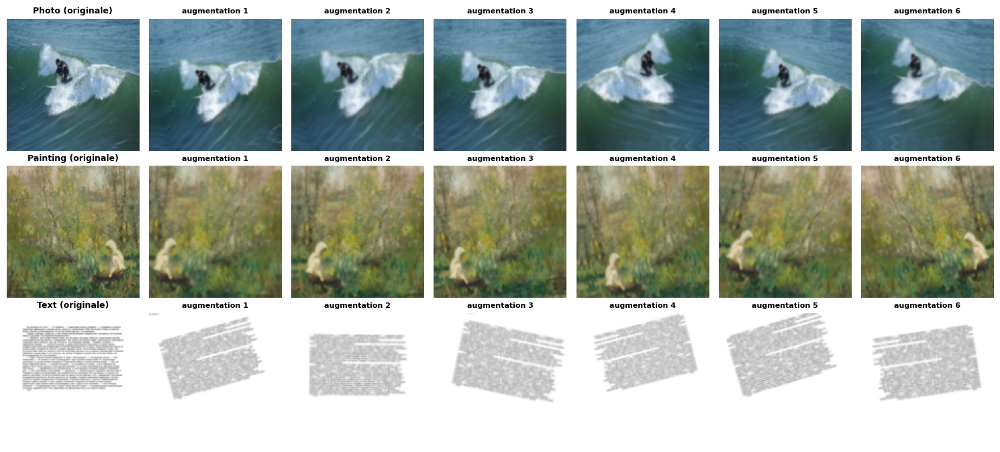

Lots par epoch : 441 | lot : x (64, 128, 128, 3) uint8, y (64,) (photos dans le lot : 16)


In [17]:
# ============================================================================
# 7.3  Générateur de lots depuis le cache
# ============================================================================
class CachedImageDataset(keras.utils.PyDataset):
    '''Fournit des lots (images uint8, étiquettes) lus dans un tableau NumPy / memmap.

    X       : tableau (N, H, W, 3) uint8 (cache)
    idx     : indices des lignes de X appartenant à ce jeu
    y       : étiquettes (même ordre que idx), ou None pour la prédiction
    shuffle : mélange à chaque epoch (entraînement uniquement)
    '''
    def __init__(self, X, idx, y=None, batch_size=64, shuffle=False, seed=SEED, **kwargs):
        super().__init__(**kwargs)
        self.X, self.idx = X, np.asarray(idx)
        self.y = None if y is None else np.asarray(y, dtype=np.float32)
        self.batch_size, self.shuffle = batch_size, shuffle
        self.rng = np.random.default_rng(seed)
        self.order = np.arange(len(self.idx))
        if shuffle:
            self.rng.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.batch_size))

    def __getitem__(self, i):
        sel = self.order[i * self.batch_size:(i + 1) * self.batch_size]
        if self.shuffle:
            sel = np.sort(sel)                   # lecture plus séquentielle du cache (ordre sans importance à l'entraînement)
        xb = self.X[self.idx[sel]]
        return xb if self.y is None else (xb, self.y[sel])

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

def make_augmentation(name='augmentation'):
    '''Bloc d'augmentation (actif uniquement pendant l'entraînement).'''
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05, fill_mode='reflect'),        # 0.05 x 2π ≈ ±18°
        layers.RandomZoom(0.10, fill_mode='reflect'),
        layers.RandomTranslation(0.05, 0.05, fill_mode='reflect'),
        layers.RandomContrast(0.10),
    ], name=name)

# Visualisation : une même image vue 6 fois par le réseau pendant l'entraînement
demo_aug = make_augmentation('demo')
fig, axes = plt.subplots(3, 7, figsize=(15, 6.8))
for r, cat in enumerate(['Photo', 'Painting', 'Text']):
    img = X1[train_df.loc[train_df['category'] == cat, 'cache_idx'].iloc[7]]
    axes[r, 0].imshow(img); axes[r, 0].set_title(f'{cat} (originale)', fontsize=9, fontweight='bold')
    for c in range(1, 7):
        aug = demo_aug(img[None].astype('float32'), training=True)[0].numpy()
        axes[r, c].imshow(np.clip(aug, 0, 255).astype('uint8')); axes[r, c].set_title(f'augmentation {c}', fontsize=8)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout(); savefig('data_augmentation'); plt.show()

ds_check = CachedImageDataset(X1, train_df['cache_idx'], y_train, batch_size=CONFIG['batch_size'], shuffle=True)
xb, yb = ds_check[0]
print(f'Lots par epoch : {len(ds_check)} | lot : x {xb.shape} {xb.dtype}, y {yb.shape} (photos dans le lot : {int(yb.sum())})')

<a id="8"></a>
## 8. Modèle 0 : référence naïve sur métadonnées (détection de biais)

Avant d'entraîner un réseau de neurones, on se pose une question de rigueur : **les métadonnées seules (taille, format, poids du fichier) suffisent-elles à reconnaître une photo ?**

Si oui, cela signifie que le jeu de données contient un **biais de collecte** : les photos proviennent d'une source unique (images de 640 px de type COCO), tandis que les autres catégories viennent d'autres sources. Un modèle pourrait alors obtenir un excellent score **sur ces données** en exploitant ce raccourci, puis échouer sur les lots réels de TouNum, où une photo scannée peut faire 3 000 px.

On entraîne une **forêt aléatoire** (scikit-learn) sur 7 métadonnées, **sans aucun pixel**. Ce modèle 0 sert :

1. de **référence** que les CNN doivent dépasser ;
2. de **mesure du biais** : il quantifie l'information de format contenue dans les données.

Modèle 0 (métadonnées) - validation : accuracy = 0.9884 | F1 = 0.9768 | ROC-AUC = 0.9986


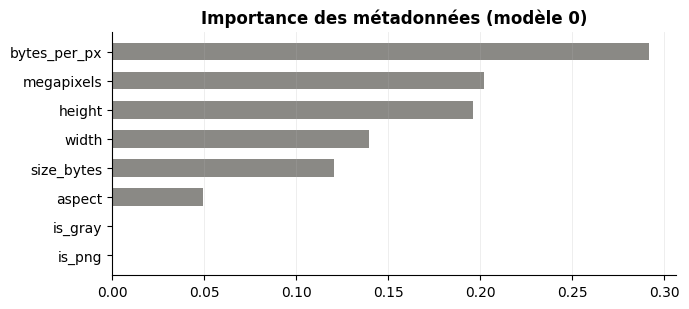

Largeur des photos : max = 640 px, 100.0% ont une largeur <= 640 px ; autres images de largeur > 640 px : 41.7%


In [18]:
# ============================================================================
# 8.1  Forêt aléatoire sur métadonnées (aucun pixel)
# ============================================================================
META_FEATS = ['width', 'height', 'aspect', 'megapixels', 'size_bytes', 'bytes_per_px', 'is_gray', 'is_png']
for d in (train_df, val_df, test_df):
    d['is_gray'] = (d['mode'] == 'L').astype(int)
    d['is_png'] = (d['format'] == 'PNG').astype(int)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_df[META_FEATS], y_train)
proba_val_m0 = rf.predict_proba(val_df[META_FEATS])[:, 1]
proba_test_m0 = rf.predict_proba(test_df[META_FEATS])[:, 1]
print(f"Modèle 0 (métadonnées) - validation : accuracy = {accuracy_score(y_val, proba_val_m0 >= 0.5):.4f} | "
      f"F1 = {f1_score(y_val, proba_val_m0 >= 0.5):.4f} | ROC-AUC = {roc_auc_score(y_val, proba_val_m0):.4f}")

imp = pd.Series(rf.feature_importances_, index=META_FEATS).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(imp.index, imp.values, color='#8a8985', height=0.6); ax.set_title('Importance des métadonnées (modèle 0)')
ax.grid(axis='y', visible=False); plt.tight_layout(); plt.show()

photo_w = df.loc[df['label'] == 1, 'width']
print(f"Largeur des photos : max = {photo_w.max():.0f} px, {(photo_w <= 640).mean():.1%} ont une largeur <= 640 px ; "
      f"autres images de largeur > 640 px : {(df.loc[df['label'] == 0, 'width'] > 640).mean():.1%}")

**Lecture : un résultat qui doit alerter.** Sans regarder **un seul pixel**, la forêt aléatoire atteint **98,8 % d'accuracy** et un F1 de 0,977 sur la validation (ROC-AUC 0,9986). Les variables les plus utiles sont le nombre d'octets par pixel (taux de compression), puis les dimensions : 100 % des photos ont une largeur ≤ 640 px.

Conséquences pour la suite :

1. **La barre est haute** : sur ce jeu de données, un CNN aura du mal à faire mieux que ce modèle trivial.
2. **Ce score est un artefact du jeu de données**, pas une compétence. Chez un client de TouNum, une photo numérisée à 300 dpi fera plusieurs milliers de pixels : le modèle 0 la rejetterait. **Il ne doit jamais être déployé.**
3. **Nos CNN ne voient pas ces métadonnées** : toutes les images sont ramenées à la même taille carrée, sans conservation du rapport d'aspect ni du poids du fichier. Ils sont donc contraints d'apprendre le **contenu visuel**. Des indices indirects peuvent subsister (netteté liée à la résolution d'origine, artefacts de compression JPEG) : ce point est repris dans le recul critique (§13).

<a id="9"></a>
## 9. Modèle 1 : CNN construit *from scratch*

### 9.1 Principe d'un réseau convolutif

Une **couche de convolution** fait glisser sur l'image de petits filtres (3×3) dont les coefficients sont **appris**. Chaque filtre produit une *carte d'activation* qui s'allume là où le motif qu'il détecte est présent. C'est la généralisation des filtres de convolution classiques (Sobel, flou gaussien) qu'on retrouvera au Livrable 2, à ceci près que les noyaux ne sont plus fixés à la main mais optimisés pour la tâche.

En empilant des couches, le réseau construit une **hiérarchie de représentations** :

- les premières couches détectent des **bords** et des **contrastes** (très efficaces pour reconnaître du texte ou des schémas) ;
- les couches intermédiaires combinent ces bords en **textures** (grain photo, touche de pinceau, trame d'impression) ;
- les couches profondes combinent les textures en **motifs** et **structures** de plus haut niveau.

### 9.2 Architecture retenue et justification de chaque choix

```
Entrée 128×128×3 (uint8)
 └─ Augmentation (entraînement seulement)
 └─ Rescaling 1/255                       -> pixels dans [0, 1]
 └─ Stem : Conv 3×3 /2, 32 filtres        -> 64×64×32
 └─ Bloc 1 : Conv 3×3 (32)  + BN + ReLU + MaxPool  -> 32×32×32
 └─ Bloc 2 : Conv 3×3 (64)  + BN + ReLU + MaxPool  -> 16×16×64
 └─ Bloc 3 : Conv 3×3 (128) + BN + ReLU + MaxPool  -> 8×8×128
 └─ Bloc 4 : Conv 3×3 (256) + BN + ReLU + MaxPool  -> 4×4×256
 └─ Conv 3×3 (256) + BN + ReLU                     -> 4×4×256
 └─ GlobalAveragePooling                           -> 256
 └─ Dropout 0.3
 └─ Dense 1 + sigmoïde                             -> P(photo)
```

| Choix | Justification |
|---|---|
| **Stem à pas 2** | divise par 4 le nombre de positions dès l'entrée ; environ 3 fois moins de calcul pour une perte d'information négligeable (entraînement sur CPU) |
| **Filtres 3×3 empilés** | deux 3×3 couvrent le même champ récepteur qu'un 5×5 avec moins de paramètres et plus de non-linéarités (principe VGG) |
| **Nombre de filtres doublé** à chaque réduction | compense la perte de résolution spatiale par plus de canaux ; le coût reste équilibré entre les blocs |
| **BatchNormalization** | normalise les activations de chaque lot : entraînement plus stable et plus rapide ; `use_bias=False` car le biais est absorbé par BN |
| **ReLU** | non-linéarité simple, sans saturation pour les valeurs positives (pas d'évanouissement du gradient) |
| **MaxPooling 2×2** | réduit la résolution et apporte une invariance locale aux petites translations |
| **GlobalAveragePooling** plutôt que `Flatten` | 256 valeurs au lieu de 4 096 : beaucoup moins de paramètres dans la couche dense, donc moins de sur-apprentissage, et un modèle compatible avec l'interprétation Grad-CAM |
| **Dropout 0.3** | désactive aléatoirement 30 % des neurones à l'entraînement ; régularisation |
| **Sigmoïde en sortie** | produit une probabilité $\hat p \in [0,1]$ pour la classe *Photo* |

### 9.3 Fonction de coût, optimiseur et callbacks

- **Coût : entropie croisée binaire pondérée** : $\mathcal{L} = -\frac{1}{N}\sum_i w_{y_i}\big[y_i\log\hat p_i + (1-y_i)\log(1-\hat p_i)\big]$. Elle pénalise fortement une prédiction confiante et fausse. Les poids $w$ (§6) compensent le déséquilibre des classes.
- **Optimiseur : Adam** (taux d'apprentissage $10^{-3}$) : descente de gradient avec moment et taux adaptatif par paramètre ; c'est le choix standard, robuste sans réglage fin.
- **Callbacks** :
  - `EarlyStopping` (patience 3 sur la perte de validation, **restauration des meilleurs poids**) : arrête l'entraînement quand le modèle commence à sur-apprendre ;
  - `ModelCheckpoint` : sauvegarde le meilleur modèle (`.keras`) au fil de l'eau ; un entraînement interrompu n'est pas perdu ;
  - `ReduceLROnPlateau` : divise le taux d'apprentissage par environ 3 quand la validation stagne, pour affiner la convergence ;
  - `CSVLogger` : journal de l'entraînement, pour la traçabilité.
- **Reprise** : la fonction `train_or_load` lance l'entraînement, ou recharge le modèle et son historique s'ils existent déjà sur disque. Pour forcer un réentraînement, passer `CONFIG['force_retrain']` à `True`.

In [19]:
# ============================================================================
# 9.4  Construction du modèle
# ============================================================================
def conv_bn_relu(x, filters, strides=1, name=None):
    x = layers.Conv2D(filters, 3, strides=strides, padding='same', use_bias=False, name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    return layers.ReLU(name=f'{name}_relu')(x)

def build_cnn_scratch(img_size=128, dropout=0.3):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='image')
    x = make_augmentation()(inputs)
    x = layers.Rescaling(1.0 / 255, name='rescaling')(x)
    x = conv_bn_relu(x, 32, strides=2, name='stem')
    for i, filters in enumerate([32, 64, 128, 256], start=1):
        x = conv_bn_relu(x, filters, name=f'block{i}')
        x = layers.MaxPooling2D(name=f'block{i}_pool')(x)
    x = conv_bn_relu(x, 256, name='head')
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(dropout, name='dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='p_photo')(x)
    return keras.Model(inputs, outputs, name='cnn_scratch')

def binary_metrics():
    return [keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc')]

def make_callbacks(name, patience=3):
    return [keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
            keras.callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, f'{name}_best.keras'), monitor='val_loss',
                                            save_best_only=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=1, min_lr=1e-6, verbose=1),
            keras.callbacks.CSVLogger(os.path.join(WORK_DIR, f'history_{name}.csv'))]

def train_or_load(model, name, fit_fn):
    '''Entraîne `model` avec fit_fn(), ou recharge son point de sauvegarde s'il existe déjà.

    Un entraînement terminé n'est jamais refait par accident. CONFIG['force_retrain'] = True force le réentraînement.
    Renvoie (historique par epoch, durée d'entraînement en secondes).'''
    ckpt = os.path.join(MODEL_DIR, f'{name}_best.keras')
    hist_path = os.path.join(WORK_DIR, f'history_{name}.json')
    if os.path.exists(ckpt) and os.path.exists(hist_path) and not CONFIG['force_retrain']:
        with open(hist_path, encoding='utf8') as f:
            saved = json.load(f)
        model.set_weights(keras.models.load_model(ckpt).get_weights())
        print(f"Point de sauvegarde trouvé : {os.path.basename(ckpt)}\n"
              f"-> poids rechargés sans réentraînement (entraîné le {saved['date']} sur {saved['device']} : "
              f"{len(saved['history']['loss'])} epochs en {saved['train_time_s'] / 60:.1f} min)")
        return saved['history'], saved['train_time_s']
    t0 = time.time()
    history = fit_fn().history
    train_time = time.time() - t0
    model.set_weights(keras.models.load_model(ckpt).get_weights())          # meilleurs poids (ModelCheckpoint)
    with open(hist_path, 'w', encoding='utf8') as f:
        json.dump({'history': history, 'train_time_s': train_time, 'date': time.strftime('%d/%m/%Y %H:%M'),
                   'device': DEVICE}, f, default=float)
    return history, train_time

keras.utils.set_random_seed(SEED)
model_cnn = build_cnn_scratch(CONFIG['img_size_cnn'])
model_cnn.compile(optimizer=keras.optimizers.Adam(CONFIG['lr_cnn']),
                  loss=keras.losses.BinaryCrossentropy(), metrics=binary_metrics())
model_cnn.summary(line_length=100)

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                         │ (None, 128, 128, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ augmentation (Sequential)                  │ (None, 128, 128, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ rescaling (Rescaling)                      │ (None, 128, 128, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ stem_conv (Conv2D)                         │ (None, 64, 64, 32)              │               864 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ stem_bn (BatchNormalization)               │ (None, 64, 64, 32)              │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ stem_relu (ReLU)                           │ (None, 64, 64, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block1_conv (Conv2D)                       │ (None, 64, 64, 32)              │             9,216 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block1_bn (BatchNormalization)             │ (None, 64, 64, 32)              │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block1_relu (ReLU)                         │ (None, 64, 64, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block1_pool (MaxPooling2D)                 │ (None, 32, 32, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block2_conv (Conv2D)                       │ (None, 32, 32, 64)              │            18,432 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block2_bn (BatchNormalization)             │ (None, 32, 32, 64)              │               256 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block2_relu (ReLU)                         │ (None, 32, 32, 64)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block2_pool (MaxPooling2D)                 │ (None, 16, 16, 64)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block3_conv (Conv2D)                       │ (None, 16, 16, 128)             │            73,728 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block3_bn (BatchNormalization)             │ (None, 16, 16, 128)             │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block3_relu (ReLU)                         │ (None, 16, 16, 128)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block3_pool (MaxPooling2D)                 │ (None, 8, 8, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ block4_conv (Conv2D)                       │ (None, 8, 8, 2

 Total params: 990,305 (3.78 MB)

 Trainable params: 988,769 (3.77 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [20]:
# ============================================================================
# 9.5  Entraînement
# ============================================================================
BS = CONFIG['batch_size']
train_ds_cnn = CachedImageDataset(X1, train_df['cache_idx'], y_train, batch_size=BS, shuffle=True)
val_ds_cnn = CachedImageDataset(X1, val_df['cache_idx'], y_val, batch_size=BS)

hist_cnn, train_time_cnn = train_or_load(model_cnn, 'cnn_scratch', lambda: model_cnn.fit(
    train_ds_cnn, validation_data=val_ds_cnn, epochs=CONFIG['epochs_cnn'], class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks('cnn_scratch'), verbose=2))
n_ep = len(hist_cnn['loss'])
print(f"Durée d'entraînement : {train_time_cnn / 60:.1f} min pour {n_ep} epochs ({train_time_cnn / n_ep / 60:.1f} min par epoch) | "
      f"meilleure epoch : {int(np.argmin(hist_cnn['val_loss'])) + 1}")

Point de sauvegarde trouvé : cnn_scratch_best.keras
-> poids rechargés sans réentraînement (entraîné le 01/10/2026 10:40 sur CPU (12 threads) : 12 epochs en 73.6 min)
Durée d'entraînement : 73.6 min pour 12 epochs (6.1 min par epoch) | meilleure epoch : 10


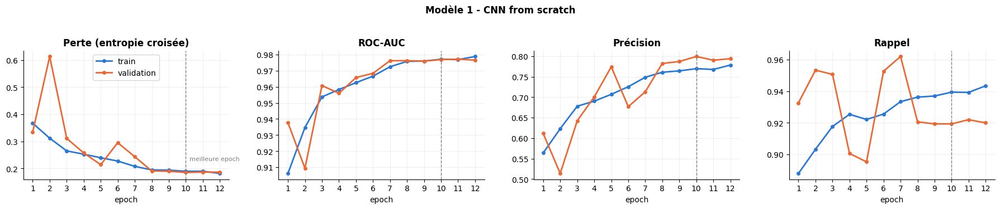

,accuracy,auc,loss,pr_auc,precision,recall,val_accuracy,val_auc,val_loss,val_pr_auc,val_precision,val_recall,learning_rate
1,0.8016,0.9061,0.3671,0.7031,0.5637,0.8879,0.8361,0.9377,0.3342,0.8035,0.6113,0.9326,0.0010
2,0.8403,0.9347,0.3117,0.7990,0.6230,0.9032,0.7644,0.9094,0.6135,0.7305,0.5137,0.9533,0.0010
3,0.8713,0.9537,0.2648,0.8580,0.6778,0.9177,0.8563,0.9607,0.3111,0.8816,0.6422,0.9506,0.0003
4,0.8784,0.9583,0.2526,0.8729,0.6902,0.9254,0.8798,0.9559,0.2571,0.8733,0.7006,0.9006,0.0003
5,0.8857,0.9625,0.2395,0.8851,0.7068,0.9221,0.9091,0.9657,0.2140,0.8981,0.7739,0.8953,0.0003
6,0.8946,0.9666,0.2273,0.8998,0.7255,0.9255,0.8753,0.9683,0.2951,0.9048,0.6768,0.9526,0.0003
7,0.9056,0.9724,0.2078,0.9186,0.7486,0.9334,0.8945,0.9762,0.2434,0.9274,0.7132,0.9620,0.0001
8,0.9111,0.9757,0.1945,0.9270,0.7608,0.9362,0.9167,0.9762,0.1906,0.9300,0.7823,0.9206,0.0000
9,0.9126,0.9759,0.1937,0.9268,0.7641,0.9370,0.9182,0.9759,0.1896,0.9307,0.7870,0.9193,0.0000
10,0.9151,0.9771,0.1896,0.9315,0.7695,0.9394,0.9227,0.9769,0.1851,0.9309,0.7993,0.9193,0.0000


In [21]:
# ============================================================================
# 9.6  Courbes d'apprentissage
# ============================================================================
def plot_history(history, title, name):
    h = pd.DataFrame(history)
    ep = np.arange(1, len(h) + 1)
    best = int(h['val_loss'].idxmin()) + 1
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
    for ax, m, t in zip(axes, ['loss', 'auc', 'precision', 'recall'],
                        ['Perte (entropie croisée)', 'ROC-AUC', 'Précision', 'Rappel']):
        ax.plot(ep, h[m], color='#2a78d6', lw=2, marker='o', ms=4, label='train')
        ax.plot(ep, h[f'val_{m}'], color='#eb6834', lw=2, marker='o', ms=4, label='validation')
        ax.axvline(best, color='gray', ls='--', lw=1)
        ax.set_title(t); ax.set_xlabel('epoch'); ax.set_xticks(ep)
    axes[0].legend(); axes[0].annotate('meilleure epoch', (best, h['val_loss'].min()), xytext=(5, 15),
                                       textcoords='offset points', fontsize=8, color='gray')
    plt.suptitle(title, fontweight='bold', y=1.03); plt.tight_layout(); savefig(name); plt.show()
    return h

h_cnn = plot_history(hist_cnn, 'Modèle 1 - CNN from scratch', 'courbes_cnn_scratch')
display(h_cnn.round(4).rename_axis('epoch').set_index(np.arange(1, len(h_cnn) + 1)))

**Lecture des courbes** :

- **Pas de sur-apprentissage** : les courbes d'entraînement et de validation restent proches du début à la fin (perte finale 0,18 contre 0,19). La régularisation (augmentation, dropout, BatchNorm) joue son rôle. Les scores de validation sont même légèrement meilleurs que ceux d'entraînement en fin de parcours, ce qui est normal : l'augmentation et le dropout ne sont actifs qu'à l'entraînement.
- **La validation est bruitée au début** (epochs 2 et 6) : avec un taux d'apprentissage de $10^{-3}$, les statistiques de BatchNorm ne sont pas encore stabilisées. `ReduceLROnPlateau` a réagi en divisant le taux d'apprentissage (à $3\cdot10^{-4}$, puis $9\cdot10^{-5}$, etc.), ce qui a stabilisé l'apprentissage.
- **Le modèle plafonne** autour de 92 % d'accuracy et 0,977 de ROC-AUC en validation (seuil 0,5). Le rappel est correct (0,92) mais la **précision est faible (0,80)** : le réseau envoie trop de non-photos au captioning. On verra en §11.4 qu'il s'agit surtout de **peintures**.
- **Diagnostic : sous-apprentissage, pas sur-apprentissage.** Un réseau d'un million de paramètres, entraîné 12 epochs sur des images de 128 px, n'a pas appris les indices fins qui séparent une peinture d'une photo. Il reste en dessous du modèle 0 (98,8 %), qui lui « triche » avec les métadonnées. Avec une patience de 1 epoch, `ReduceLROnPlateau` a aussi réduit le taux d'apprentissage très tôt, ce qui a freiné la progression : c'est un réglage à assouplir (voir §13).
- Deux leviers existent : entraîner plus longtemps un réseau plus gros (coûteux sur CPU, réaliste sur GPU), ou **réutiliser des caractéristiques visuelles déjà apprises** sur des millions d'images. C'est l'objet du modèle 2.

<a id="10"></a>
## 10. Modèle 2 : Transfer Learning (EfficientNetB0) et fine-tuning

### 10.1 Principe

Le **transfer learning** réutilise un réseau déjà entraîné sur une très grande base, ici **ImageNet** (1,2 million de photos, 1 000 classes). Ses couches convolutives ont appris des détecteurs génériques de bords, de textures et de formes, qui sont pertinents pour notre tâche : distinguer le **grain d'une photographie** de la **touche d'une peinture** relève précisément de l'analyse de texture.

On obtient ainsi un modèle performant avec peu de calcul, et moins de risque de sur-apprentissage qu'un réseau appris de zéro.

### 10.2 Choix du réseau : EfficientNetB0

| Critère | EfficientNetB0 |
|---|---|
| Paramètres | 4,0 M (sans la tête de classification) |
| Précision ImageNet (top-1) | environ 77 % : le meilleur rapport précision / coût de sa génération |
| Architecture | blocs *MBConv* (convolutions séparables en profondeur) + *Squeeze-and-Excitation* (pondération des canaux) ; profondeur, largeur et résolution équilibrées (*compound scaling*) |
| Prétraitement | **intégré au modèle** (normalisation interne) : il reçoit directement des pixels [0, 255] |

Résolution utilisée : **160×160** plutôt que 224×224, soit un calcul 2 fois moindre (contrainte CPU) pour une perte de précision limitée. Sur ce poste, l'extraction des caractéristiques des 40 257 images a pris **10 minutes** (environ 67 images/s) ; elle n'est faite qu'une fois, puis mise en cache.

### 10.3 Deux stratégies, évaluées toutes les deux

1. **Modèle 2 : extraction de caractéristiques (backbone gelé)**. Chaque image traverse **une seule fois** EfficientNet, qui la résume en un vecteur de **1 280 caractéristiques**. On entraîne ensuite une petite tête dense sur ces vecteurs. C'est très rapide (quelques secondes par epoch) et c'est exactement l'idée de « représentation compacte » évoquée dans le sujet pour le Livrable 3.
2. **Modèle 2b : fine-tuning partiel**. On part du modèle 2 et on **dégèle les derniers blocs** d'EfficientNet (blocs 6, 7 et la convolution finale), réentraînés avec un **taux d'apprentissage 10 fois plus faible** ($10^{-4}$) et de la data augmentation. Les caractéristiques de haut niveau s'adaptent ainsi à notre domaine (documents numérisés). Les couches `BatchNormalization` restent gelées, sinon les statistiques apprises sur ImageNet seraient détruites par nos petits lots.

In [22]:
# ============================================================================
# 10.4  Extraction des caractéristiques EfficientNetB0 (une seule passe, mise en cache)
# ============================================================================
S2 = CONFIG['img_size_tl']
backbone = keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                             input_shape=(S2, S2, 3), pooling='avg')
backbone.trainable = False
print(f'EfficientNetB0 : {backbone.count_params():,} paramètres (gelés), sortie {backbone.output_shape}')

FEAT_PATH = os.path.join(CACHE_DIR, f'features_effnetb0_{S2}.npy')
need_idx = np.sort(df['cache_idx'].values)
if os.path.exists(FEAT_PATH):
    FEATS = np.load(FEAT_PATH)
    print('Caractéristiques rechargées depuis le cache :', FEATS.shape)
else:
    extract = tf.function(lambda x: backbone(x, training=False), reduce_retracing=True)
    FEATS = np.zeros((X2.shape[0], backbone.output_shape[-1]), dtype=np.float32)
    t0, bs = time.time(), 64
    for k, start in enumerate(range(0, len(need_idx), bs)):
        rows = need_idx[start:start + bs]
        FEATS[rows] = extract(tf.convert_to_tensor(X2[rows], dtype=tf.float32)).numpy()
        if (k + 1) % 100 == 0:
            done = start + len(rows); el = time.time() - t0
            print(f'  {done:>6,}/{len(need_idx):,} images | {el / 60:4.1f} min | {done / el:4.0f} img/s')
    np.save(FEAT_PATH, FEATS)
    print(f'Extraction terminée en {(time.time() - t0) / 60:.1f} min -> {FEATS.shape}')

F_train, F_val, F_test = (FEATS[d['cache_idx'].values] for d in (train_df, val_df, test_df))

EfficientNetB0 : 4,049,571 paramètres (gelés), sortie (None, 1280)
Caractéristiques rechargées depuis le cache : (40737, 1280)


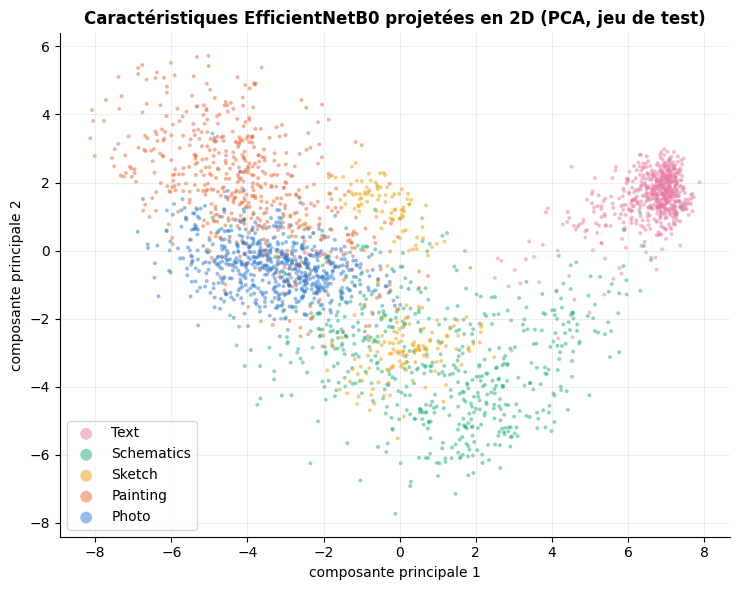

In [23]:
# ============================================================================
# 10.5  Visualisation de l'espace des caractéristiques (PCA 2D)
# ============================================================================
from sklearn.decomposition import PCA
sub = pd.concat([d.sample(min(len(d), 600), random_state=SEED) for _, d in test_df.groupby('category')])
proj = PCA(n_components=2, random_state=SEED).fit(F_train).transform(FEATS[sub['cache_idx'].values])
fig, ax = plt.subplots(figsize=(7.5, 6))
for cat in ['Text', 'Schematics', 'Sketch', 'Painting', 'Photo']:
    m = (sub['category'] == cat).values
    ax.scatter(proj[m, 0], proj[m, 1], s=8, alpha=0.5, color=CAT_COLORS[cat], label=cat, edgecolors='none')
ax.set_title('Caractéristiques EfficientNetB0 projetées en 2D (PCA, jeu de test)')
ax.set_xlabel('composante principale 1'); ax.set_ylabel('composante principale 2')
ax.legend(markerscale=3, loc='lower left'); plt.tight_layout(); savefig('pca_features'); plt.show()

**Lecture** : même **sans aucun apprentissage** sur nos données, les caractéristiques ImageNet organisent déjà les catégories. Les textes forment un groupe isolé ; les schémas et les croquis s'étalent dans une zone distincte ; les peintures sont **voisines des photos**, avec une zone de recouvrement. Cette projection ne montre que 2 dimensions sur 1 280 : la tête de classification exploitera l'ensemble pour départager photos et peintures.

Point de sauvegarde trouvé : head_tl_best.keras
-> poids rechargés sans réentraînement (entraîné le 01/10/2026 10:51 sur CPU (12 threads) : 15 epochs en 0.5 min)
Tête : 15 epochs en 28 s (328,193 paramètres entraînables) | meilleure epoch : 10


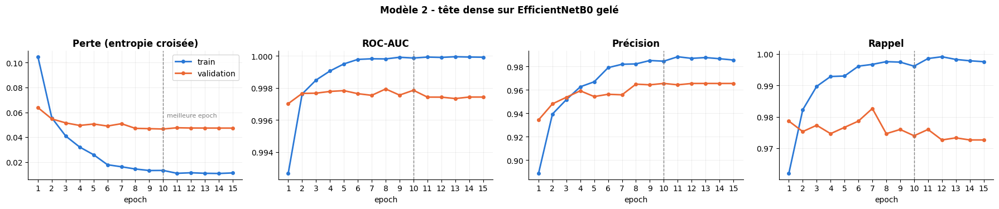

Cohérence modèle complet / tête sur features (écart max) : 0.0


In [24]:
# ============================================================================
# 10.6  Modèle 2 : tête de classification sur caractéristiques gelées
# ============================================================================
def build_head(dim, name='head_tl'):
    inputs = keras.Input(shape=(dim,), name='features')
    x = layers.Dropout(0.2, name='drop_in')(inputs)
    x = layers.Dense(256, activation='relu', name='dense')(x)
    x = layers.Dropout(0.4, name='drop_hidden')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='p_photo')(x)
    return keras.Model(inputs, outputs, name=name)

keras.utils.set_random_seed(SEED)
head = build_head(F_train.shape[1])
head.compile(optimizer=keras.optimizers.Adam(CONFIG['lr_head']), loss=keras.losses.BinaryCrossentropy(),
             metrics=binary_metrics())
hist_head, train_time_head = train_or_load(head, 'head_tl', lambda: head.fit(
    F_train, y_train, validation_data=(F_val, y_val), epochs=CONFIG['epochs_head'], batch_size=128,
    class_weight=CLASS_WEIGHT, callbacks=make_callbacks('head_tl', patience=5), verbose=0))
print(f"Tête : {len(hist_head['loss'])} epochs en {train_time_head:.0f} s ({head.count_params():,} paramètres entraînables) | "
      f"meilleure epoch : {int(np.argmin(hist_head['val_loss'])) + 1}")
h_head = plot_history(hist_head, 'Modèle 2 - tête dense sur EfficientNetB0 gelé', 'courbes_tl_head')

# Modèle complet déployable : image -> EfficientNet -> tête
img_in = keras.Input(shape=(S2, S2, 3), name='image')
model_tl = keras.Model(img_in, head(backbone(img_in, training=False)), name='effnetb0_frozen')
check = model_tl.predict(X2[test_df['cache_idx'].values[:64]], verbose=0).ravel()
print('Cohérence modèle complet / tête sur features (écart max) :',
      float(np.abs(check - head.predict(F_test[:64], verbose=0).ravel()).max()))

Paramètres entraînables : 3,458,077 / 4,377,764
Point de sauvegarde trouvé : effnetb0_finetuned_best.keras
-> poids rechargés sans réentraînement (entraîné le 01/10/2026 11:29 sur CPU (12 threads) : 3 epochs en 37.8 min)
Fine-tuning : 37.8 min pour 3 epochs (12.6 min par epoch)


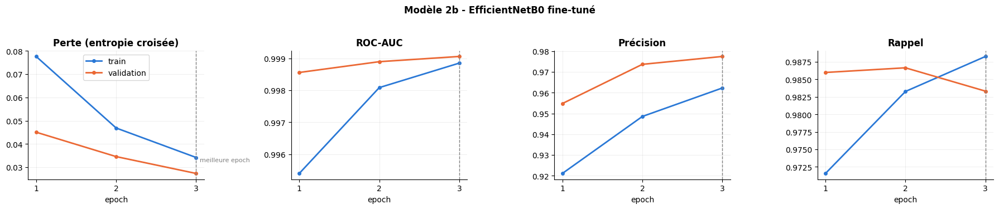

,accuracy,auc,loss,pr_auc,precision,recall,val_accuracy,val_auc,val_loss,val_pr_auc,val_precision,val_recall,learning_rate
epoch,,,,,,,,,,,,,
1,0.9723,0.9954,0.0776,0.9856,0.9211,0.9716,0.9849,0.9986,0.0451,0.9946,0.9548,0.9860,0.0001
2,0.9826,0.9981,0.0469,0.9932,0.9486,0.9833,0.9901,0.9989,0.0346,0.9948,0.9737,0.9867,0.0001
3,0.9875,0.9989,0.0342,0.9961,0.9623,0.9883,0.9902,0.9991,0.0273,0.9975,0.9775,0.9833,0.0001


In [25]:
# ============================================================================
# 10.7  Modèle 2b : fine-tuning partiel (blocs 6, 7 et convolution finale)
# ============================================================================
keras.utils.set_random_seed(SEED)
ft_backbone = keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                input_shape=(S2, S2, 3), pooling='avg')
ft_backbone.trainable = True
for layer in ft_backbone.layers:
    trainable_block = layer.name.startswith(('block6', 'block7', 'top'))
    layer.trainable = trainable_block and not isinstance(layer, layers.BatchNormalization)

ft_head = build_head(F_train.shape[1], name='head_ft')
ft_head.set_weights(head.get_weights())                     # départ : la tête déjà entraînée (modèle 2)

inputs = keras.Input(shape=(S2, S2, 3), name='image')
x = make_augmentation()(inputs)
x = ft_backbone(x, training=False)                           # BN en mode inférence
model_ft = keras.Model(inputs, ft_head(x), name='effnetb0_finetuned')
model_ft.compile(optimizer=keras.optimizers.Adam(CONFIG['lr_ft']), loss=keras.losses.BinaryCrossentropy(),
                 metrics=binary_metrics())
n_train = sum(int(np.prod(w.shape)) for w in model_ft.trainable_weights)
print(f'Paramètres entraînables : {n_train:,} / {model_ft.count_params():,}')

train_ds_tl = CachedImageDataset(X2, train_df['cache_idx'], y_train, batch_size=32, shuffle=True)
val_ds_tl = CachedImageDataset(X2, val_df['cache_idx'], y_val, batch_size=64)
hist_ft, train_time_ft = train_or_load(model_ft, 'effnetb0_finetuned', lambda: model_ft.fit(
    train_ds_tl, validation_data=val_ds_tl, epochs=CONFIG['epochs_ft'], class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks('effnetb0_finetuned', patience=2), verbose=2))
n_ep = len(hist_ft['loss'])
print(f"Fine-tuning : {train_time_ft / 60:.1f} min pour {n_ep} epochs ({train_time_ft / n_ep / 60:.1f} min par epoch)")
h_ft = plot_history(hist_ft, 'Modèle 2b - EfficientNetB0 fine-tuné', 'courbes_tl_finetune')
display(h_ft.round(4).set_index(np.arange(1, len(h_ft) + 1)).rename_axis('epoch'))

**Lecture** :

- **Modèle 2 (backbone gelé)** : en **28 secondes** d'entraînement de la tête (après 10 minutes d'extraction, faite une seule fois), on atteint **98,5 % d'accuracy** et 0,998 de ROC-AUC en validation. C'est très au-dessus du CNN maison (92,3 %), entraîné pendant 74 minutes. La perte d'entraînement (0,011) passe nettement sous la perte de validation (0,047) : la tête commence à sur-apprendre, et l'*early stopping* l'arrête après 15 epochs en restaurant les poids de l'epoch 10.
- **Modèle 2b (fine-tuning)** : en adaptant les derniers blocs, la perte de validation descend de 0,047 à **0,027** et l'accuracy monte à **99,0 %**. La perte baissait encore à la 3ᵉ epoch : quelques epochs supplémentaires (peu coûteuses sur GPU) apporteraient probablement un gain. Les scores d'entraînement restent en dessous de ceux de validation, car l'augmentation rend la tâche plus difficile à l'entraînement : il n'y a aucun signe de sur-apprentissage.
- **Coût** : le fine-tuning a demandé 38 minutes sur CPU, contre 28 secondes pour la tête seule. Le gain devra être confirmé sur le jeu de test, avec un test statistique (§11.3).

<a id="11"></a>
## 11. Évaluation approfondie et pertinence statistique

### Protocole

1. Chaque modèle est rechargé depuis son **meilleur point de sauvegarde** (epoch de perte de validation minimale).
2. Le **seuil de décision** $\tau$ de chaque modèle est choisi **sur la validation** (celui qui maximise le F1). Le seuil par défaut de 0,5 n'a aucune raison d'être optimal quand les classes sont déséquilibrées.
3. Les performances sont mesurées **sur le jeu de test**, qui n'a servi à **aucune décision** (ni entraînement, ni arrêt, ni seuil, ni choix de modèle). C'est la seule estimation honnête du comportement sur de nouvelles images.

In [26]:
# ============================================================================
# 11.1  Prédictions (validation + test) et choix du seuil sur la validation
# ============================================================================
def restore_best(model, name):
    '''Recharge dans `model` les poids du meilleur point de sauvegarde (ModelCheckpoint).'''
    model.set_weights(keras.models.load_model(os.path.join(MODEL_DIR, f'{name}_best.keras')).get_weights())

def predict_cached(model, X, d, batch_size=64):
    return model.predict(CachedImageDataset(X, d['cache_idx'], batch_size=batch_size), verbose=0).ravel()

restore_best(model_cnn, 'cnn_scratch'); restore_best(head, 'head_tl'); restore_best(model_ft, 'effnetb0_finetuned')

t0 = time.time()
PROBA = {
    'M0 Métadonnées':       {'val': proba_val_m0, 'test': proba_test_m0},
    'M1 CNN scratch':       {'val': predict_cached(model_cnn, X1, val_df), 'test': predict_cached(model_cnn, X1, test_df)},
    'M2 EffNet gelé':       {'val': head.predict(F_val, verbose=0).ravel(), 'test': head.predict(F_test, verbose=0).ravel()},
    'M2b EffNet fine-tuné': {'val': predict_cached(model_ft, X2, val_df), 'test': predict_cached(model_ft, X2, test_df)},
}
print(f'Prédictions calculées en {time.time() - t0:.0f} s')
MODELS = list(PROBA)
np.savez(os.path.join(WORK_DIR, 'predictions.npz'), y_val=y_val, y_test=y_test,
         **{f'{m}|{s}': PROBA[m][s] for m in MODELS for s in ('val', 'test')})

def best_f1_threshold(y, p):
    '''Seuil maximisant le F1 (calculé sur la validation).'''
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    return float(thr[np.argmax(f1)])

def compute_metrics(y, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {'seuil': thr, 'accuracy': accuracy_score(y, yhat), 'précision': precision_score(y, yhat, zero_division=0),
            'rappel': recall_score(y, yhat), 'F1': f1_score(y, yhat), 'spécificité': tn / (tn + fp),
            'ROC-AUC': roc_auc_score(y, p), 'PR-AUC': average_precision_score(y, p), 'FP': int(fp), 'FN': int(fn)}

THRESH = {m: best_f1_threshold(y_val, PROBA[m]['val']) for m in MODELS}
res_val = pd.DataFrame({m: compute_metrics(y_val, PROBA[m]['val'], THRESH[m]) for m in MODELS}).T.astype(float)
res_test = pd.DataFrame({m: compute_metrics(y_test, PROBA[m]['test'], THRESH[m]) for m in MODELS}).T.astype(float)
res_test05 = pd.DataFrame({m: compute_metrics(y_test, PROBA[m]['test'], 0.5) for m in MODELS}).T.astype(float)

fmt = {c: '{:.4f}' for c in res_test.columns if c not in ('FP', 'FN')} | {'FP': '{:.0f}', 'FN': '{:.0f}'}
print(f'VALIDATION ({len(y_val):,} images) - seuil optimisé :'); display(res_val.style.format(fmt))
print(f'TEST ({len(y_test):,} images, dont {y_test.sum():,} photos) - seuil choisi sur la validation :')
display(res_test.style.format(fmt).highlight_max(subset=['accuracy', 'précision', 'rappel', 'F1', 'ROC-AUC', 'PR-AUC'], color='#cde2fb'))
print('TEST - seuil par défaut 0,5 (pour comparaison) :'); display(res_test05.style.format(fmt))

Prédictions calculées en 234 s
VALIDATION (6,039 images) - seuil optimisé :


,seuil,accuracy,précision,rappel,F1,spécificité,ROC-AUC,PR-AUC,FP,FN
M0 Métadonnées,0.5140,0.9887,0.9710,0.9840,0.9775,0.9903,0.9986,0.9953,44,24
M1 CNN scratch,0.6987,0.9329,0.8671,0.8619,0.8645,0.9564,0.9769,0.9328,198,207
M2 EffNet gelé,0.4691,0.9854,0.9638,0.9780,0.9709,0.9879,0.9984,0.9940,55,33
M2b EffNet fine-tuné,0.5887,0.9909,0.9820,0.9813,0.9816,0.9941,0.9994,0.9979,27,28


TEST (6,039 images, dont 1,499 photos) - seuil choisi sur la validation :


,seuil,accuracy,précision,rappel,F1,spécificité,ROC-AUC,PR-AUC,FP,FN
M0 Métadonnées,0.5140,0.9921,0.9827,0.9853,0.9840,0.9943,0.9991,0.9969,26,22
M1 CNN scratch,0.6987,0.9301,0.8592,0.8592,0.8592,0.9535,0.9756,0.9339,211,211
M2 EffNet gelé,0.4691,0.9841,0.9618,0.9746,0.9682,0.9872,0.9982,0.9947,58,38
M2b EffNet fine-tuné,0.5887,0.9887,0.9792,0.9753,0.9773,0.9932,0.9988,0.9969,31,37


TEST - seuil par défaut 0,5 (pour comparaison) :


,seuil,accuracy,précision,rappel,F1,spécificité,ROC-AUC,PR-AUC,FP,FN
M0 Métadonnées,0.5000,0.9922,0.9821,0.9867,0.9844,0.9941,0.9991,0.9969,27,20
M1 CNN scratch,0.5000,0.9180,0.7882,0.9159,0.8473,0.9187,0.9756,0.9339,369,126
M2 EffNet gelé,0.5000,0.9836,0.9617,0.9726,0.9672,0.9872,0.9982,0.9947,58,41
M2b EffNet fine-tuné,0.5000,0.9889,0.9767,0.9787,0.9777,0.9923,0.9988,0.9969,35,32


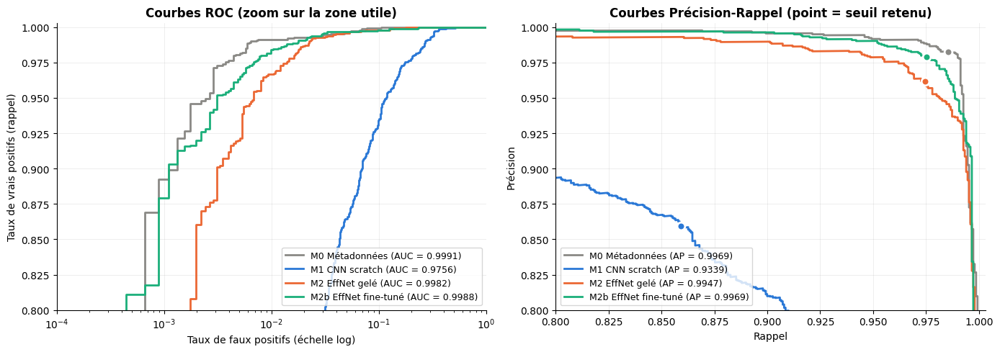

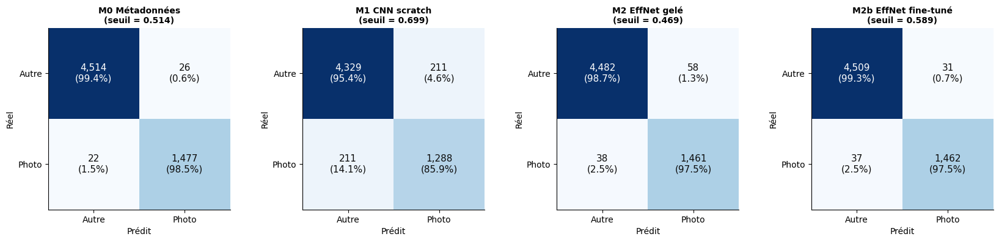

In [27]:
# ============================================================================
# 11.2  Courbes ROC et Précision-Rappel, matrices de confusion (jeu de test)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in MODELS:
    p = PROBA[m]['test']
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(np.maximum(fpr, 1e-4), tpr, lw=2, color=MODEL_COLORS[m], label=f"{m} (AUC = {roc_auc_score(y_test, p):.4f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, lw=2, color=MODEL_COLORS[m], label=f"{m} (AP = {average_precision_score(y_test, p):.4f})")
    yhat = p >= THRESH[m]
    axes[1].scatter(recall_score(y_test, yhat), precision_score(y_test, yhat), s=60, color=MODEL_COLORS[m],
                    edgecolors='white', linewidths=2, zorder=5)
axes[0].set_xscale('log'); axes[0].set_xlim(1e-4, 1); axes[0].set_ylim(0.8, 1.003)
axes[0].set_xlabel('Taux de faux positifs (échelle log)'); axes[0].set_ylabel('Taux de vrais positifs (rappel)')
axes[0].set_title('Courbes ROC (zoom sur la zone utile)'); axes[0].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0.8, 1.003); axes[1].set_ylim(0.8, 1.003)
axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Précision')
axes[1].set_title('Courbes Précision-Rappel (point = seuil retenu)'); axes[1].legend(loc='lower left', fontsize=9)
plt.tight_layout(); savefig('eval_roc_pr'); plt.show()

fig, axes = plt.subplots(1, len(MODELS), figsize=(4.2 * len(MODELS), 3.9))
for ax, m in zip(axes, MODELS):
    cm = confusion_matrix(y_test, PROBA[m]['test'] >= THRESH[m], labels=[0, 1])
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}\n({cm[i, j] / cm[i].sum():.1%})', ha='center', va='center', fontsize=11,
                    color='white' if cm[i, j] > cm.max() / 2 else '#0b0b0b')
    ax.set_xticks([0, 1], ['Autre', 'Photo']); ax.set_yticks([0, 1], ['Autre', 'Photo'])
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel'); ax.set_title(f'{m}\n(seuil = {THRESH[m]:.3f})', fontsize=10); ax.grid(False)
plt.tight_layout(); savefig('eval_confusion'); plt.show()

**Lecture des résultats globaux (jeu de test, 6 039 images)** :

| Modèle | Accuracy | Précision | Rappel | F1 | ROC-AUC | Erreurs (FP + FN) |
|---|---|---|---|---|---|---|
| M0 Métadonnées (référence biaisée) | 99,2 % | 0,983 | 0,985 | 0,984 | 0,9991 | 26 + 22 = 48 |
| M1 CNN from scratch | 93,0 % | 0,859 | 0,859 | 0,859 | 0,9756 | 211 + 211 = 422 |
| M2 EfficientNetB0 gelé | 98,4 % | 0,962 | 0,975 | 0,968 | 0,9982 | 58 + 38 = 96 |
| **M2b EfficientNetB0 fine-tuné** | **98,9 %** | **0,979** | **0,975** | **0,977** | **0,9988** | **31 + 37 = 68** |

- **Le transfer learning change d'échelle** : le modèle 2b fait **6 fois moins d'erreurs** que le CNN maison (68 contre 422). Sur 100 images envoyées au captioning, environ 98 sont de vraies photos (précision 0,979), et 97,5 % des photos sont retenues (rappel).
- **Les scores de test sont cohérents avec ceux de validation** (F1 de 0,977 en test contre 0,982 en validation pour M2b) : le modèle généralise, et le choix du seuil sur la validation n'a pas sur-ajusté.
- **Le seuil optimisé compte** : pour M1, passer de 0,5 à 0,70 équilibre précision et rappel. Pour M2b, le seuil retenu (0,59) reste proche de 0,5.
- **Le modèle 0 reste devant** sur ce jeu de test (48 erreurs). Ce n'est pas un argument en sa faveur, mais un avertissement sur les données : il exploite la taille des fichiers, pas leur contenu (voir §8). La comparaison statistique est faite ci-dessous.

### 11.3 Les écarts entre modèles sont-ils statistiquement significatifs ?

Un score mesuré sur environ 6 000 images de test est une **estimation** entachée d'incertitude. Deux outils permettent de conclure rigoureusement :

- **Intervalle de confiance à 95 % par bootstrap** : on rééchantillonne 1 000 fois le jeu de test avec remise et on recalcule chaque métrique. L'intervalle entre les quantiles 2,5 % et 97,5 % indique la plage plausible de la vraie performance.
- **Test de McNemar** (exact) : pour comparer deux modèles **sur les mêmes images**, on ne regarde que les cas discordants (l'un a raison, l'autre a tort). Sous l'hypothèse nulle « les deux modèles ont le même taux d'erreur », ces cas se répartissent à 50/50. Une *p-value* inférieure à 0,05 permet de rejeter cette hypothèse.

Jeu de test : estimation ponctuelle [intervalle de confiance à 95 %, bootstrap 1 000 tirages]


,accuracy,précision,rappel,F1,ROC-AUC
M0 Métadonnées,0.9921 [0.9897 ; 0.9940],0.9827 [0.9748 ; 0.9887],0.9853 [0.9792 ; 0.9906],0.9840 [0.9792 ; 0.9883],0.9991 [0.9985 ; 0.9995]
M1 CNN scratch,0.9301 [0.9228 ; 0.9363],0.8592 [0.8404 ; 0.8776],0.8592 [0.8425 ; 0.8765],0.8592 [0.8446 ; 0.8724],0.9756 [0.9721 ; 0.9788]
M2 EffNet gelé,0.9841 [0.9806 ; 0.9871],0.9618 [0.9522 ; 0.9709],0.9746 [0.9662 ; 0.9820],0.9682 [0.9615 ; 0.9744],0.9982 [0.9976 ; 0.9988]
M2b EffNet fine-tuné,0.9887 [0.9859 ; 0.9912],0.9792 [0.9717 ; 0.9860],0.9753 [0.9671 ; 0.9829],0.9773 [0.9718 ; 0.9823],0.9988 [0.9982 ; 0.9993]


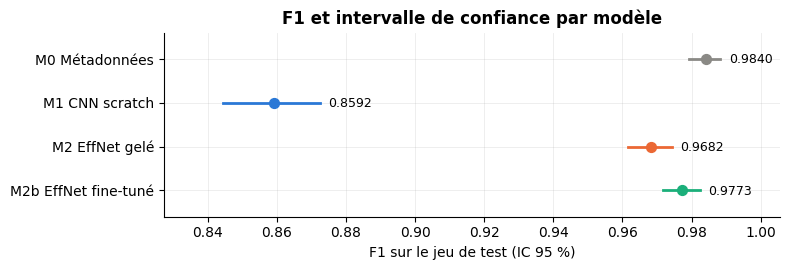

Tests de McNemar (exacts) sur le jeu de test :


,modèle A,modèle B,A seul correct,B seul correct,p-value,conclusion (α = 5 %)
0,M0 Métadonnées,M1 CNN scratch,412,38,1.93e-80,A meilleur
1,M1 CNN scratch,M2 EffNet gelé,55,381,4.39e-61,B meilleur
2,M1 CNN scratch,M2b EffNet fine-tuné,37,391,1.08e-75,B meilleur
3,M2 EffNet gelé,M2b EffNet fine-tuné,29,57,3.35e-03,B meilleur
4,M0 Métadonnées,M2b EffNet fine-tuné,66,46,7.21e-02,différence non significative


In [28]:
# ============================================================================
# 11.3  Intervalles de confiance (bootstrap) et tests de McNemar
# ============================================================================
def bootstrap_ci(y, p, thr, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    yhat = (p >= thr).astype(int)
    stats_ = {k: [] for k in ('accuracy', 'précision', 'rappel', 'F1', 'ROC-AUC')}
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        yy, hh = y[i], yhat[i]
        tp = int(((yy == 1) & (hh == 1)).sum()); fp = int(((yy == 0) & (hh == 1)).sum()); fn = int(((yy == 1) & (hh == 0)).sum())
        stats_['accuracy'].append((yy == hh).mean())
        stats_['précision'].append(tp / max(tp + fp, 1)); stats_['rappel'].append(tp / max(tp + fn, 1))
        stats_['F1'].append(2 * tp / max(2 * tp + fp + fn, 1)); stats_['ROC-AUC'].append(roc_auc_score(yy, p[i]))
    return {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in stats_.items()}

CI = {m: bootstrap_ci(y_test, PROBA[m]['test'], THRESH[m]) for m in MODELS}
ci_table = pd.DataFrame({m: {k: f"{res_test.loc[m, k]:.4f}  [{lo:.4f} ; {hi:.4f}]" for k, (lo, hi) in CI[m].items()} for m in MODELS}).T
print('Jeu de test : estimation ponctuelle [intervalle de confiance à 95 %, bootstrap 1 000 tirages]')
display(ci_table)

fig, ax = plt.subplots(figsize=(8, 2.8))
for k, m in enumerate(MODELS[::-1]):
    lo, hi = CI[m]['F1']; v = res_test.loc[m, 'F1']
    ax.plot([lo, hi], [k, k], color=MODEL_COLORS[m], lw=2); ax.scatter(v, k, color=MODEL_COLORS[m], s=50, zorder=3)
    ax.annotate(f'{v:.4f}', (hi, k), xytext=(6, -3), textcoords='offset points', fontsize=9)
ax.set_yticks(range(len(MODELS)), MODELS[::-1]); ax.set_xlabel('F1 sur le jeu de test (IC 95 %)')
ax.set_title('F1 et intervalle de confiance par modèle'); ax.margins(x=0.12, y=0.2)
plt.tight_layout(); savefig('eval_ic_f1'); plt.show()

def mcnemar(y, pa, ta, pb, tb):
    ok_a, ok_b = (pa >= ta) == y, (pb >= tb) == y
    b, c = int((ok_a & ~ok_b).sum()), int((~ok_a & ok_b).sum())     # A seul juste / B seul juste
    pval = stats.binomtest(min(b, c), b + c, 0.5).pvalue if b + c else 1.0
    return b, c, pval

rows = []
for a, b_ in [('M0 Métadonnées', 'M1 CNN scratch'), ('M1 CNN scratch', 'M2 EffNet gelé'),
              ('M1 CNN scratch', 'M2b EffNet fine-tuné'), ('M2 EffNet gelé', 'M2b EffNet fine-tuné'),
              ('M0 Métadonnées', 'M2b EffNet fine-tuné')]:
    b, c, pval = mcnemar(y_test.astype(bool), PROBA[a]['test'], THRESH[a], PROBA[b_]['test'], THRESH[b_])
    rows.append({'modèle A': a, 'modèle B': b_, 'A seul correct': b, 'B seul correct': c, 'p-value': pval,
                 'conclusion (α = 5 %)': ('B meilleur' if c > b else 'A meilleur') if pval < 0.05 else 'différence non significative'})
print('Tests de McNemar (exacts) sur le jeu de test :')
display(pd.DataFrame(rows).style.format({'p-value': '{:.2e}'}))

**Lecture** :

- **Les intervalles de confiance sont étroits** : le F1 du modèle retenu (M2b) vaut 0,977, avec un intervalle à 95 % de [0,972 ; 0,982]. Les intervalles de M1 et de M2b sont très éloignés : leur écart ne doit rien au hasard.
- **M2b est significativement meilleur que M2** (McNemar : 57 images où seul M2b a raison, contre 29 dans l'autre sens ; p = 0,003). Le fine-tuning apporte donc un gain réel, et pas seulement une fluctuation d'échantillonnage.
- **M2b et M0 ne sont pas statistiquement distinguables** sur ce jeu de test (66 contre 46 cas discordants ; p = 0,07) : on ne peut pas affirmer que les métadonnées font mieux que le CNN. En revanche, M0 dépend de la taille des fichiers et ne se transposera pas à d'autres données, alors que M2b s'appuie sur le contenu visuel.

### 11.4 Analyse par sous-catégorie

La métrique globale masque des situations très différentes. On mesure ici, pour chaque sous-catégorie, le **taux d'erreur** : la part de photos manquées pour *Photo* (faux négatifs), et la part d'images prises à tort pour des photos dans les autres catégories (faux positifs). C'est le tableau qui répond directement aux deux niveaux d'exigence de TouNum (§1.4).

Nombre d'erreurs par sous-catégorie :


,n test,M0 Métadonnées,M1 CNN scratch,M2 EffNet gelé,M2b EffNet fine-tuné
Photo,1499,22,211,38,37
Painting,1499,25,170,48,26
Schematics,1330,1,41,10,5
Text,1500,0,0,0,0
Sketch,211,0,0,0,0


Taux d'erreur (%) par sous-catégorie :


,M0 Métadonnées,M1 CNN scratch,M2 EffNet gelé,M2b EffNet fine-tuné
Photo,1.47,14.08,2.54,2.47
Painting,1.67,11.34,3.20,1.73
Schematics,0.08,3.08,0.75,0.38
Text,0.00,0.00,0.00,0.00
Sketch,0.00,0.00,0.00,0.00


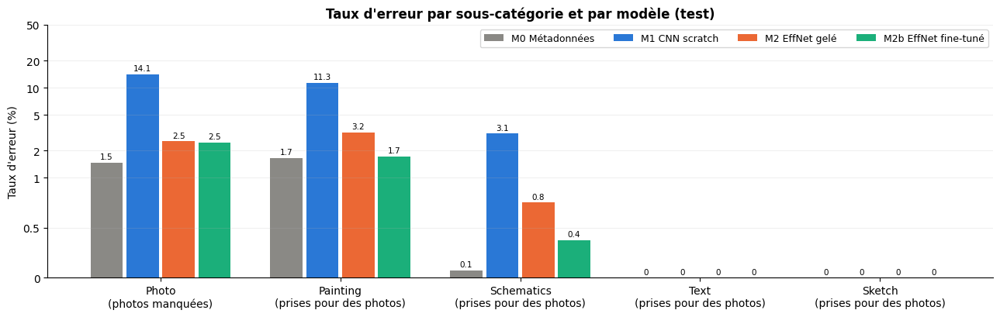

In [29]:
# ============================================================================
# 11.4  Taux d'erreur par sous-catégorie (jeu de test)
# ============================================================================
cats_test = test_df['category'].values
err = pd.DataFrame({m: {c: ((PROBA[m]['test'] >= THRESH[m]).astype(int) != y_test)[cats_test == c].mean() * 100 for c in order}
                    for m in MODELS})
nerr = pd.DataFrame({m: {c: int(((PROBA[m]['test'] >= THRESH[m]).astype(int) != y_test)[cats_test == c].sum()) for c in order}
                     for m in MODELS})
nerr.insert(0, 'n test', [int((cats_test == c).sum()) for c in order])
print("Nombre d'erreurs par sous-catégorie :"); display(nerr)
print("Taux d'erreur (%) par sous-catégorie :"); display(err.round(2))

fig, ax = plt.subplots(figsize=(13, 4.2))
w = 0.8 / len(MODELS)
for k, m in enumerate(MODELS):
    xs = np.arange(len(order)) + (k - (len(MODELS) - 1) / 2) * w
    bars = ax.bar(xs, err[m].values, width=w * 0.9, color=MODEL_COLORS[m], label=m)
    ax.bar_label(bars, labels=[f'{v:.1f}' if v >= 0.05 else '0' for v in err[m].values], fontsize=7.5, padding=2)
ax.set_xticks(np.arange(len(order)), [f'{c}\n(' + ('photos manquées' if c == 'Photo' else 'prises pour des photos') + ')' for c in order])
ax.set_ylabel("Taux d'erreur (%)"); ax.set_title("Taux d'erreur par sous-catégorie et par modèle (test)")
ax.set_yscale('symlog', linthresh=1); ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50], ['0', '0.5', '1', '2', '5', '10', '20', '50'])
ax.legend(ncol=4, fontsize=9, loc='upper right'); ax.grid(axis='x', visible=False)
plt.tight_layout(); savefig('eval_par_categorie'); plt.show()

**Lecture : réponse aux deux niveaux d'exigence de TouNum** :

- **Exigence minimale (photo vs texte / schéma) : atteinte.** Sur les 1 500 textes et 211 croquis du test, **aucune erreur**, quel que soit le modèle, y compris le CNN maison. Sur les 1 330 schémas, M2b ne laisse passer que **5 images (0,4 %)**.
- **Exigence idéale (photo vs peinture) : largement atteinte par M2b**, avec **26 peintures sur 1 499 (1,7 %)** prises pour des photos, contre 170 (11,3 %) pour le CNN maison.
- **Où se concentrent les erreurs restantes** : sur les **photos rejetées** (37, soit 2,5 %) et les **peintures acceptées**. Le fine-tuning a presque divisé par deux les erreurs sur les peintures (48 → 26) et sur les schémas (10 → 5), mais n'a presque pas changé le nombre de photos manquées (38 → 37) : ce sont des photos atypiques, examinées en §11.6.

### 11.5 Zoom sur le cas critique : Photo vs Painting

On restreint le jeu de test aux seules photos et peintures. C'est un problème binaire **équilibré** et **difficile** : il isole la capacité du modèle à distinguer une photographie d'une œuvre peinte, sans l'aide des cas faciles (texte, schémas).

Sous-ensemble Photo + Painting du test : 2,998 images (1,499 photos, 1,499 peintures)


,accuracy,précision,rappel,F1,ROC-AUC,peintures prises pour des photos,photos rejetées
M0 Métadonnées,0.9843,0.9834,0.9853,0.9843,0.9975,25,22
M1 CNN scratch,0.8729,0.8834,0.8592,0.8712,0.9408,170,211
M2 EffNet gelé,0.9713,0.9682,0.9746,0.9714,0.9956,48,38
M2b EffNet fine-tuné,0.9790,0.9825,0.9753,0.9789,0.9969,26,37


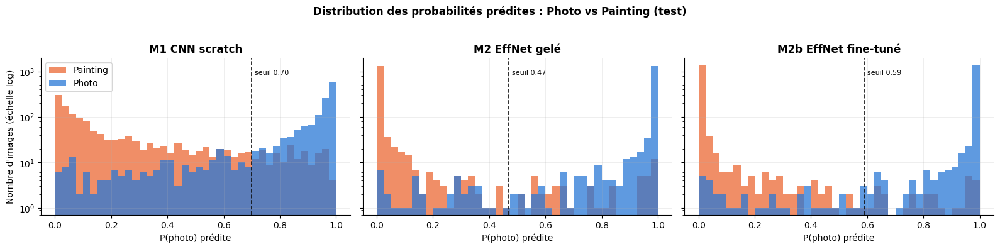

In [30]:
# ============================================================================
# 11.5  Photo vs Painting
# ============================================================================
mask_pp = np.isin(cats_test, ['Photo', 'Painting'])
y_pp = y_test[mask_pp]
pp = pd.DataFrame({m: {
    'accuracy': accuracy_score(y_pp, PROBA[m]['test'][mask_pp] >= THRESH[m]),
    'précision': precision_score(y_pp, PROBA[m]['test'][mask_pp] >= THRESH[m]),
    'rappel': recall_score(y_pp, PROBA[m]['test'][mask_pp] >= THRESH[m]),
    'F1': f1_score(y_pp, PROBA[m]['test'][mask_pp] >= THRESH[m]),
    'ROC-AUC': roc_auc_score(y_pp, PROBA[m]['test'][mask_pp]),
    'peintures prises pour des photos': int(((PROBA[m]['test'] >= THRESH[m]) & (cats_test == 'Painting')).sum()),
    'photos rejetées': int(((PROBA[m]['test'] < THRESH[m]) & (cats_test == 'Photo')).sum()),
} for m in MODELS}).T
print(f"Sous-ensemble Photo + Painting du test : {mask_pp.sum():,} images ({int(y_pp.sum()):,} photos, {int((1 - y_pp).sum()):,} peintures)")
display(pp.style.format({c: '{:.4f}' for c in ['accuracy', 'précision', 'rappel', 'F1', 'ROC-AUC']} |
                        {'peintures prises pour des photos': '{:.0f}', 'photos rejetées': '{:.0f}'}))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, m in zip(axes, MODELS[1:]):
    p = PROBA[m]['test']
    ax.hist(p[cats_test == 'Painting'], bins=bins, color=CAT_COLORS['Painting'], alpha=0.75, label='Painting')
    ax.hist(p[cats_test == 'Photo'], bins=bins, color=CAT_COLORS['Photo'], alpha=0.75, label='Photo')
    ax.axvline(THRESH[m], color='#0b0b0b', ls='--', lw=1.2); ax.set_yscale('log')
    ax.annotate(f'seuil {THRESH[m]:.2f}', (THRESH[m], 0.95), xycoords=('data', 'axes fraction'), xytext=(4, -4),
                textcoords='offset points', fontsize=8, va='top')
    ax.set_title(m); ax.set_xlabel('P(photo) prédite')
axes[0].set_ylabel("Nombre d'images (échelle log)"); axes[0].legend()
plt.suptitle('Distribution des probabilités prédites : Photo vs Painting (test)', fontweight='bold', y=1.03)
plt.tight_layout(); savefig('eval_photo_vs_painting'); plt.show()

**Lecture** : sur ce sous-problème équilibré et difficile, M2b atteint **97,9 % d'accuracy** et une ROC-AUC de **0,997**, contre 87,3 % et 0,941 pour le CNN maison.

Les histogrammes montrent pourquoi. Le CNN maison répartit ses prédictions sur tout l'intervalle [0, 1] : il **hésite**, et les deux distributions se recouvrent largement. Les modèles EfficientNet concentrent les peintures près de 0 et les photos près de 1 : il ne reste qu'une **fine traînée d'images ambiguës** entre les deux (l'axe vertical est logarithmique : ces barres ne représentent que quelques images chacune).

Conséquence pratique : avec M2b, on peut définir une **zone d'incertitude** (par exemple P(photo) entre 0,2 et 0,8) et envoyer ces rares images en vérification manuelle, au lieu de trancher automatiquement.

### 11.6 Analyse visuelle des erreurs

Regarder les erreurs est indispensable : cela permet de distinguer les **vraies faiblesses du modèle** des **erreurs d'étiquetage** du jeu de données, et d'identifier les types d'images à surveiller en production. On affiche les erreurs les plus « confiantes » du meilleur modèle (sélectionné sur la validation).

Modèle retenu (meilleur F1 de validation) : M2b EffNet fine-tuné | seuil = 0.589
Faux positifs : 31 (par catégorie : {'Painting': 26, 'Schematics': 5}) | Faux négatifs : 37


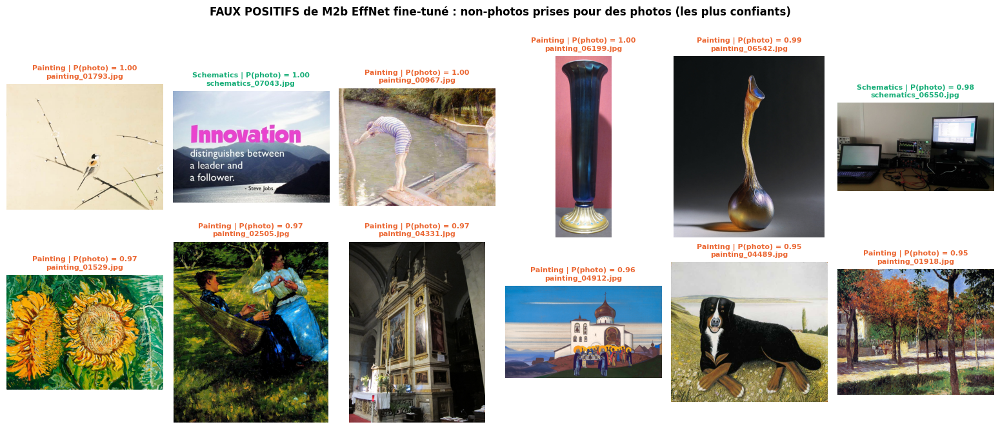

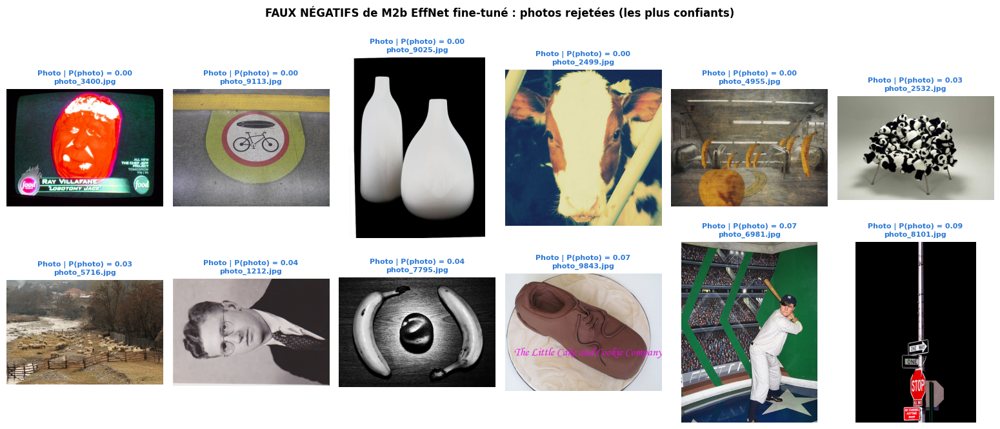

In [31]:
# ============================================================================
# 11.6  Galerie des erreurs du meilleur modèle (jeu de test)
# ============================================================================
BEST = res_val.drop(index='M0 Métadonnées')['F1'].astype(float).idxmax()       # choix du modèle sur la VALIDATION
print(f'Modèle retenu (meilleur F1 de validation) : {BEST} | seuil = {THRESH[BEST]:.3f}')

p_best = PROBA[BEST]['test']
test_res = test_df.assign(proba=p_best, pred=(p_best >= THRESH[BEST]).astype(int))
fp_df = test_res[(test_res['pred'] == 1) & (test_res['label'] == 0)].sort_values('proba', ascending=False)
fn_df = test_res[(test_res['pred'] == 0) & (test_res['label'] == 1)].sort_values('proba')
print(f'Faux positifs : {len(fp_df)} (par catégorie : {fp_df["category"].value_counts().to_dict()}) | Faux négatifs : {len(fn_df)}')

def show_gallery(d, title, n=12, ncols=6):
    d = d.head(n)
    if len(d) == 0:
        print(f'{title} : aucune erreur'); return
    nrows = int(np.ceil(len(d) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis('off')
    for ax, (_, r) in zip(axes, d.iterrows()):
        img = iio.imread(r['path'])
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(f"{r['category']} | P(photo) = {r['proba']:.2f}\n{r['filename']}", fontsize=8,
                     color=CAT_COLORS[r['category']], fontweight='bold')
    plt.suptitle(title, fontweight='bold', y=1.0); plt.tight_layout(h_pad=2.0); plt.show()

show_gallery(fp_df, f'FAUX POSITIFS de {BEST} : non-photos prises pour des photos (les plus confiants)')
show_gallery(fn_df, f'FAUX NÉGATIFS de {BEST} : photos rejetées (les plus confiants)')

**Lecture : une partie des « erreurs » sont des erreurs d'étiquetage, pas du modèle.**

*Faux positifs (31 au total : 26 peintures, 5 schémas).* Parmi les 12 plus confiants :

- **au moins 5 sont en réalité des photographies mal rangées** : deux **vases en verre** photographiés (`painting_06199`, `painting_06542`), un **intérieur d'église** (`painting_04331`), une **photo de matériel de laboratoire** (`schematics_06550`) et une diapositive dont le fond est une **photo de paysage** (`schematics_07043`). Le modèle a raison contre l'étiquette ;
- les autres sont de **vraies peintures réalistes** (scènes impressionnistes, portrait de chien, tournesols) : c'est la limite attendue du problème.

*Faux négatifs (37 photos rejetées).* Ce sont des **photos atypiques** : capture d'un écran de télévision, marquage au sol, objets sur fond noir uni, photos fortement **filtrées** ou en noir et blanc, portrait ancien scanné de travers, image avec texte incrusté. Leur apparence s'écarte de celle d'une photo « naturelle ».

**Conséquences** :

1. La performance réelle du modèle est **meilleure que celle mesurée** : le jeu de test contient du bruit d'étiquetage, qui fixe un plafond aux scores atteignables.
2. Pour TouNum, la définition métier de « photo » doit être précisée : une photographie d'une œuvre d'art, une capture d'écran ou une photo très retouchée doivent-elles être légendées ? Cette décision relève du client, pas du modèle.
3. Un **nettoyage des étiquettes** assisté par le modèle (revue manuelle des quelques dizaines d'images où le modèle contredit l'étiquette avec une forte confiance) est une piste d'amélioration peu coûteuse.

### 11.7 Interprétabilité : que regarde le CNN ? (Grad-CAM)

**Grad-CAM** calcule, pour une image, les zones qui ont le plus contribué à la décision : on pondère les cartes d'activation d'une couche convolutive par le gradient du score de sortie. On l'applique au **modèle 1** (CNN maison) sur la couche `block3` (carte 16×16).

- Pour une image prédite *photo*, les zones claires sont celles qui **poussent vers « photo »**.
- Pour une image prédite *autre*, ce sont celles qui **poussent vers « autre »**.

C'est un outil de confiance pour la soutenance : il permet de vérifier que le modèle s'appuie sur le **contenu** (textures, traits, fonds) et non sur un artefact.

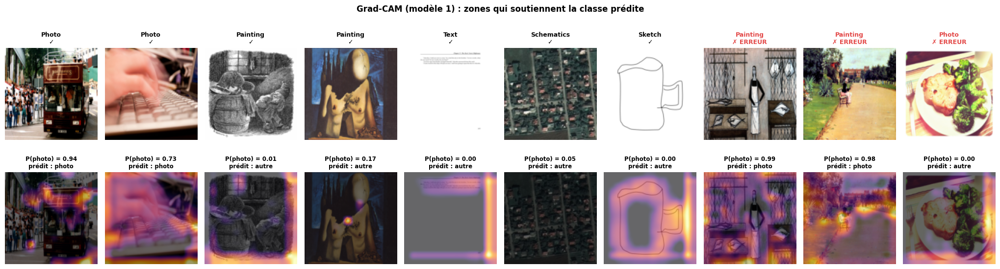

In [32]:
# ============================================================================
# 11.7  Grad-CAM sur le CNN from scratch
# ============================================================================
def grad_cam(model, images, layer_name='block3_relu'):
    '''Renvoie (cartes Grad-CAM normalisées [0,1], probabilités) pour un lot d'images uint8.
    La carte est calculée pour la classe prédite (photo si p >= 0.5, sinon autre).'''
    sub = keras.Model(model.inputs, [model.get_layer(layer_name).output, model.get_layer('gap').output])
    W, b = model.get_layer('p_photo').get_weights()
    x = tf.convert_to_tensor(images, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv, pooled = sub(x, training=False)
        logit = tf.squeeze(tf.matmul(pooled, W) + b, axis=-1)            # score avant sigmoïde (pas de saturation)
        signed = tf.where(logit >= 0, logit, -logit)                      # évidence en faveur de la classe prédite
    grads = tape.gradient(signed, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(conv * weights, axis=-1))
    cam = cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)
    cam = tf.image.resize(cam[..., None], images.shape[1:3], method='bicubic')[..., 0]
    return np.clip(cam.numpy(), 0, 1), tf.sigmoid(logit).numpy()

p_m1 = PROBA['M1 CNN scratch']['test']
t_m1 = test_df.assign(proba=p_m1, pred=(p_m1 >= THRESH['M1 CNN scratch']).astype(int))
picks = pd.concat([
    t_m1[(t_m1['category'] == 'Photo') & (t_m1['pred'] == 1)].sample(2, random_state=SEED),
    t_m1[(t_m1['category'] == 'Painting') & (t_m1['pred'] == 0)].sample(2, random_state=SEED),
    t_m1[(t_m1['category'] == 'Text') & (t_m1['pred'] == 0)].sample(1, random_state=SEED),
    t_m1[(t_m1['category'] == 'Schematics') & (t_m1['pred'] == 0)].sample(1, random_state=SEED),
    t_m1[(t_m1['category'] == 'Sketch') & (t_m1['pred'] == 0)].sample(1, random_state=SEED),
    t_m1[(t_m1['category'] == 'Painting') & (t_m1['pred'] == 1)].sort_values('proba', ascending=False).head(2),
    t_m1[(t_m1['category'] == 'Photo') & (t_m1['pred'] == 0)].sort_values('proba').head(1),
])
imgs = X1[picks['cache_idx'].values]
cams, probs = grad_cam(model_cnn, imgs)

fig, axes = plt.subplots(2, len(picks), figsize=(2.05 * len(picks), 5.6))
for k, (_, r) in enumerate(picks.iterrows()):
    ok_ = r['pred'] == r['label']
    axes[0, k].imshow(imgs[k]); axes[0, k].set_title(f"{r['category']}\n{'✓' if ok_ else '✗ ERREUR'}", fontsize=9,
                                                    color='#0b0b0b' if ok_ else '#e34948', fontweight='bold')
    axes[1, k].imshow(imgs[k]); axes[1, k].imshow(cams[k], cmap='inferno', alpha=0.6, vmin=0, vmax=1)
    axes[1, k].set_title(f"P(photo) = {probs[k]:.2f}\nprédit : {'photo' if r['pred'] else 'autre'}", fontsize=8.5)
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('Grad-CAM (modèle 1) : zones qui soutiennent la classe prédite', fontweight='bold', y=1.02)
plt.tight_layout(h_pad=3.0); savefig('eval_gradcam'); plt.show()

**Lecture** :

- **Photos correctement classées** : les activations couvrent les zones **texturées** de la scène (foule, véhicule, clavier). Le réseau s'appuie sur le contenu.
- **Texte et croquis** : les activations se concentrent le long des **traits** et surtout sur les **bords de l'image**. Le réseau a appris qu'un **fond blanc uniforme qui s'étend jusqu'aux bords** signale un document. C'est un indice efficace, mais **fragile**.
- **La preuve par l'erreur** : la photo de la dernière colonne (une assiette) est rejetée avec P(photo) = 0,00. Elle possède un **cadre blanc arrondi**, et la carte d'activation s'allume précisément sur ce cadre. Le CNN maison a confondu « bord blanc » et « document ».
- **Peintures prises pour des photos** : les activations sont diffuses sur toute l'image ; aucun indice local ne les distingue pour ce réseau peu profond.

Grad-CAM confirme donc le diagnostic du §9 : le CNN maison s'appuie sur des indices de **bas niveau** (fond, bords, contraste), suffisants pour l'exigence minimale mais pas pour le cas Photo vs Painting.

### 11.8 Robustesse aux dégradations (lien avec le Livrable 2)

TouNum numérise à la chaîne : les images réelles peuvent être **bruitées**, **floues** ou **fortement compressées**. Or le filtre binaire est placé **avant** l'étape de débruitage dans le workflow. Il faut donc vérifier qu'il résiste à ces dégradations, sinon il faudrait inverser l'ordre des modules.

On dégrade artificiellement un échantillon du jeu de test (jusqu'à 300 images par sous-catégorie) et on mesure le rappel sur les photos et la spécificité sur les autres images, **sans réentraîner** les modèles.

Échantillon de robustesse : 1411 images (300 photos)


rappel photo                                      \
modèle              M1 CNN scratch M2 EffNet gelé M2b EffNet fine-tuné   
dégradation                                                              
Original                     0.887          0.973                0.983   
Bruit gaussien σ=15          0.667          0.893                0.753   
Bruit gaussien σ=40          0.077          0.570                0.310   
Sel et poivre 5 %            0.430          0.650                0.747   
Flou gaussien r=1            0.760          0.957                0.957   
Flou gaussien r=2.5          0.467          0.770                0.770   
JPEG qualité 10              0.960          0.863                0.817   

                       spécificité                                      
modèle              M1 CNN scratch M2 EffNet gelé M2b EffNet fine-tuné  
dégradation                                                             
Original                     0.965          0.985                0.993  
Bruit gaussien σ=15          0.988          0.982                0.997  
Bruit gaussien σ=40          0.996          0.986                0.999  
Sel et poivre 5 %            0.978          0.987                0.990  
Flou gaussien r=1            0.981          0.982                0.995  
Flou gaussien r=2.5          0.981          0.973                0.995  
JPEG qualité 10              0.900          0.981                0.989

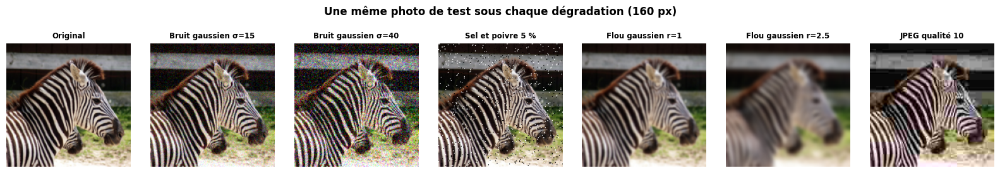

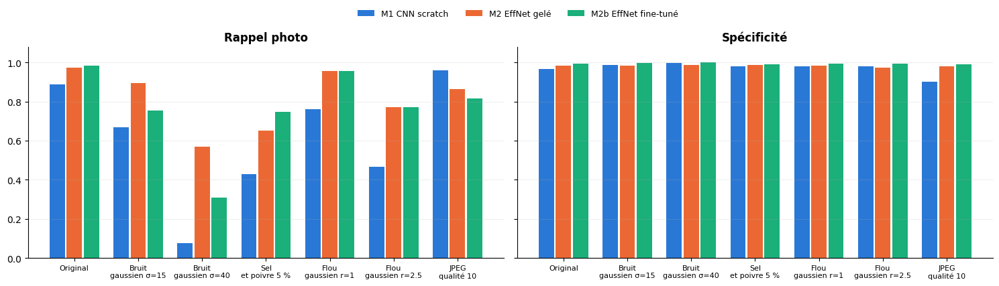

In [33]:
# ============================================================================
# 11.8  Test de robustesse : bruit, flou, compression
# ============================================================================
def add_gaussian_noise(a, sigma, rng):
    return np.clip(a.astype(np.float32) + rng.normal(0, sigma, a.shape), 0, 255).astype(np.uint8)
def add_salt_pepper(a, amount, rng):
    out = a.copy(); u = rng.random(a.shape[:2])
    out[u < amount / 2] = 0; out[u > 1 - amount / 2] = 255
    return out
def gaussian_blur(a, radius, rng=None):
    return np.asarray(Image.fromarray(a).filter(ImageFilter.GaussianBlur(radius)))
def jpeg_compress(a, quality, rng=None):
    buf = io.BytesIO(); Image.fromarray(a).save(buf, format='JPEG', quality=quality)
    return np.asarray(Image.open(buf).convert('RGB'))

DEGRADATIONS = {
    'Original':               lambda a, rng: a,
    'Bruit gaussien σ=15':    lambda a, rng: add_gaussian_noise(a, 15, rng),
    'Bruit gaussien σ=40':    lambda a, rng: add_gaussian_noise(a, 40, rng),
    'Sel et poivre 5 %':      lambda a, rng: add_salt_pepper(a, 0.05, rng),
    'Flou gaussien r=1':      lambda a, rng: gaussian_blur(a, 1),
    'Flou gaussien r=2.5':    lambda a, rng: gaussian_blur(a, 2.5),
    'JPEG qualité 10':        lambda a, rng: jpeg_compress(a, 10),
}
rob_df = pd.concat([d.sample(min(len(d), 300), random_state=SEED) for _, d in test_df.groupby('category')]).sort_values('cache_idx')
y_rob = rob_df['label'].values
ROB_MODELS = {'M1 CNN scratch': (model_cnn, X1), 'M2 EffNet gelé': (model_tl, X2), 'M2b EffNet fine-tuné': (model_ft, X2)}

rows, examples = [], {}
for dname, fn in DEGRADATIONS.items():
    for mname, (model, X) in ROB_MODELS.items():
        rng = np.random.default_rng(SEED)
        Xd = np.stack([fn(a, rng) for a in X[rob_df['cache_idx'].values]])
        if mname == 'M2 EffNet gelé':
            examples[dname] = Xd[np.flatnonzero(y_rob == 1)[5]]
        yhat = model.predict(Xd, batch_size=64, verbose=0).ravel() >= THRESH[mname]
        rows.append({'dégradation': dname, 'modèle': mname, 'accuracy': (yhat == y_rob).mean(),
                     'rappel photo': yhat[y_rob == 1].mean(), 'spécificité': 1 - yhat[y_rob == 0].mean()})
rob = pd.DataFrame(rows)
print(f'Échantillon de robustesse : {len(rob_df)} images ({int(y_rob.sum())} photos)')
display(rob.pivot(index='dégradation', columns='modèle', values=['rappel photo', 'spécificité']).reindex(list(DEGRADATIONS)).round(3))

fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(2.3 * len(DEGRADATIONS), 2.6))
for ax, (dname, img) in zip(axes, examples.items()):
    ax.imshow(img); ax.set_title(dname, fontsize=8.5); ax.axis('off')
plt.suptitle('Une même photo de test sous chaque dégradation (160 px)', fontweight='bold', y=1.04); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
names = list(DEGRADATIONS); w = 0.8 / len(ROB_MODELS)
for ax, metric in zip(axes, ['rappel photo', 'spécificité']):
    for k, mname in enumerate(ROB_MODELS):
        vals = rob[rob['modèle'] == mname].set_index('dégradation').loc[names, metric].values
        ax.bar(np.arange(len(names)) + (k - 1) * w, vals, width=w * 0.9, color=MODEL_COLORS[mname], label=mname)
    ax.set_xticks(np.arange(len(names)), [n.replace(' ', '\n', 1) for n in names], fontsize=8)
    ax.set_title(metric.capitalize()); ax.set_ylim(0, 1.08); ax.grid(axis='x', visible=False)
plt.tight_layout()
axes[0].legend(fontsize=9, loc='lower center', bbox_to_anchor=(1.03, 1.10), ncol=3, frameon=False)
savefig('eval_robustesse'); plt.show()

**Lecture : le résultat le plus important pour l'architecture du workflow.**

- **La spécificité ne bouge pas** (entre 0,989 et 0,999 pour M2b selon la condition) : une image dégradée n'est presque jamais prise à tort pour une photo.
- **Le rappel s'effondre** : sur des photos bruitées ou floues, le modèle répond « autre ». Pour M2b, le rappel passe de 0,98 à **0,75** avec un bruit modéré (σ = 15), à **0,31** avec un bruit fort (σ = 40), à **0,77** avec un flou marqué, et à 0,82 avec une compression JPEG très forte.
- **Explication probable** : les modèles ont appris qu'une photo est une image **nette et propre**. Le bruit et le flou détruisent les textures fines sur lesquelles ils s'appuient ; une photo dégradée sort alors de ce qu'ils ont vu à l'entraînement.
- **Le fine-tuning a spécialisé le modèle** : M2 (backbone gelé) résiste mieux au bruit gaussien que M2b (0,89 contre 0,75 pour σ = 15). M2b est meilleur sur des images propres, mais plus sensible à ce qui sort de sa distribution d'entraînement.

**Recommandations pour TouNum** :

1. **Placer le débruitage (Livrable 2) avant le filtre binaire**, ou au moins l'appliquer aux images rejetées avant une seconde passe. L'ordre « classification puis débruitage » ferait perdre une part importante des photos de mauvaise qualité, celles-là mêmes que le débruitage doit sauver.
2. **Réentraîner avec une augmentation par bruit et flou** (transformations écartées en §7.2, à réintroduire) pour rendre le filtre robuste par construction.

Limite de ce test : les dégradations sont appliquées sur les images déjà réduites (128 ou 160 px). Un bruit présent sur le scan d'origine serait en partie atténué par la réduction de taille : l'effet réel est donc probablement moins sévère, mais la tendance est claire.

### 11.9 Temps d'inférence

Pour un service de numérisation à la chaîne, le **débit** compte autant que la précision. On mesure, sur la machine d'exécution :

- le coût du **prétraitement** (lecture du fichier, décodage, redimensionnement), commun à tous les modèles ;
- le coût du **modèle** en traitement unitaire (1 image) et par lots de 64 images ;
- la **taille** du modèle sur disque.

In [34]:
# ============================================================================
# 11.9  Temps d'inférence par image
# ============================================================================
bench_paths = test_df.sample(100, random_state=SEED)['path'].tolist()
t0 = time.perf_counter()
for p in bench_paths:
    _ = load_image_array(p, CONFIG['img_size_tl'])
prep_ms = (time.perf_counter() - t0) / len(bench_paths) * 1000

def bench_model(model, X, n_single=40, n_batches=6, bs=64):
    idx = test_df['cache_idx'].values
    fn = tf.function(lambda x: model(x, training=False), reduce_retracing=True)
    x1 = tf.convert_to_tensor(X[idx[:1]], tf.float32); xb = tf.convert_to_tensor(X[idx[:bs]], tf.float32)
    fn(x1); fn(xb)                                             # échauffement (traçage du graphe)
    t = time.perf_counter()
    for k in range(n_single):
        fn(tf.convert_to_tensor(X[idx[k:k + 1]], tf.float32)).numpy()
    single_ms = (time.perf_counter() - t) / n_single * 1000
    t = time.perf_counter()
    for k in range(n_batches):
        fn(tf.convert_to_tensor(X[idx[k * bs:(k + 1) * bs]], tf.float32)).numpy()
    batch_ms = (time.perf_counter() - t) / (n_batches * bs) * 1000
    return single_ms, batch_ms

SAVED = {'M1 CNN scratch': 'cnn_scratch_best.keras', 'M2 EffNet gelé': 'effnetb0_frozen.keras',
         'M2b EffNet fine-tuné': 'effnetb0_finetuned_best.keras'}
model_tl.save(os.path.join(MODEL_DIR, SAVED['M2 EffNet gelé']))
rows = []
for mname, (model, X) in ROB_MODELS.items():
    s_ms, b_ms = bench_model(model, X)
    rows.append({'modèle': mname, 'entrée': f'{X.shape[1]}x{X.shape[2]}', 'paramètres': model.count_params(),
                 'taille disque (Mo)': os.path.getsize(os.path.join(MODEL_DIR, SAVED[mname])) / 1e6,
                 'modèle seul, unitaire (ms/img)': s_ms, 'modèle seul, lot de 64 (ms/img)': b_ms,
                 'bout en bout, lot de 64 (ms/img)': b_ms + prep_ms})
timing = pd.DataFrame(rows).set_index('modèle')
timing['images / s (bout en bout)'] = 1000 / timing['bout en bout, lot de 64 (ms/img)']
timing['100 000 images (min)'] = 100000 * timing['bout en bout, lot de 64 (ms/img)'] / 60000
device = 'GPU' if gpus else f'CPU ({os.cpu_count()} threads)'
print(f'Matériel : {device} | prétraitement (lecture + décodage + redimensionnement) : {prep_ms:.1f} ms / image (1 thread)')
display(timing.style.format({'paramètres': '{:,.0f}', 'taille disque (Mo)': '{:.1f}', 'modèle seul, unitaire (ms/img)': '{:.1f}',
                             'modèle seul, lot de 64 (ms/img)': '{:.2f}', 'bout en bout, lot de 64 (ms/img)': '{:.1f}',
                             'images / s (bout en bout)': '{:.0f}', '100 000 images (min)': '{:.0f}'}))

Matériel : CPU (12 threads) | prétraitement (lecture + décodage + redimensionnement) : 38.4 ms / image (1 thread)


,entrée,paramètres,taille disque (Mo),"modèle seul, unitaire (ms/img)","modèle seul, lot de 64 (ms/img)","bout en bout, lot de 64 (ms/img)",images / s (bout en bout),100 000 images (min)
modèle,,,,,,,,
M1 CNN scratch,128x128,"990,305",12.0,13.1,2.56,40.9,24,68
M2 EffNet gelé,160x160,"4,377,764",18.4,65.4,18.15,56.5,18,94
M2b EffNet fine-tuné,160x160,"4,377,764",46.1,96.1,19.60,58.0,17,97


**Lecture** (les temps varient de quelques millisecondes d'une exécution à l'autre, selon la charge de la machine) :

- **Le prétraitement pèse plus que le modèle** : lire et décoder un fichier prend de l'ordre de 40 ms par image sur ce poste (un seul thread, disque lent), contre environ **20 ms** pour le passage dans EfficientNet (par lots) et **3 ms** pour le CNN maison. Le premier levier d'accélération est donc la **lecture des fichiers en parallèle**, ce que fait le module de production (§12) avec 8 threads : il atteint 46 images/s de bout en bout sur le lot de démonstration (§12.5), contre 17 images/s ici avec un seul thread.
- **En traitement unitaire**, le modèle livré (M2b) répond en environ **100 ms** par image sur CPU : c'est compatible avec un usage interactif.
- **Le traitement par lots est indispensable** pour la numérisation à la chaîne : il divise le coût du modèle par 5 environ (20 ms contre 100 ms par image).
- **Taille des modèles** : 12 Mo (M1), 18 Mo (M2) et 46 Mo (point de sauvegarde de M2b, qui contient aussi l'état de l'optimiseur ; le modèle livré, sans cet état, pèse 18 Mo). Tous sont déployables sur un serveur standard, sans GPU.
- Ces mesures valent pour **ce poste sans GPU**. Sur un GPU, le passage dans le réseau serait plus rapide ; le prétraitement resterait le facteur limitant.

<a id="12"></a>
## 12. Industrialisation : sauvegarde et fonction `predict_is_photo`

Pour que TouNum puisse **mettre en production et maintenir** la solution, le résultat de ce livrable n'est pas le notebook lui-même mais trois artefacts autonomes :

| Artefact | Rôle |
|---|---|
| `outputs_livrable1/models/<modèle>.keras` | le modèle retenu, au format natif Keras (architecture + poids + prétraitement intégré) |
| `outputs_livrable1/models/photo_filter_config.json` | la **configuration de production** : fichier du modèle, taille d'entrée, **seuil de décision**, métriques de référence, versions des bibliothèques |
| `tounum_photo_filter.py` | un **module Python sans dépendance au notebook** : `predict_is_photo(image_path)` pour une image, `predict_folder(dossier)` pour un lot |

Le Livrable 3 n'aura qu'à écrire `from tounum_photo_filter import predict_is_photo`. Changer de modèle ou de seuil se fait en modifiant le fichier JSON, **sans toucher au code**.

In [35]:
# ============================================================================
# 12.1  Sauvegarde du modèle retenu et de sa configuration de production
# ============================================================================
import datetime, shutil

final_model = ROB_MODELS[BEST][0]
final_size = int(ROB_MODELS[BEST][1].shape[1])
FINAL_MODEL_FILE = 'photo_filter_model.keras'
final_model.save(os.path.join(MODEL_DIR, FINAL_MODEL_FILE))

prod_config = {
    'model_name': BEST,
    'model_file': FINAL_MODEL_FILE,
    'img_size': final_size,
    'draft_size': CONFIG['draft_size'],
    'threshold': round(THRESH[BEST], 4),
    'positive_label': 'photo', 'negative_label': 'autre',
    'input': 'image RGB uint8 [0, 255], redimensionnée en bilinéaire ; normalisation intégrée au modèle',
    'test_metrics': {k: round(float(v), 4) for k, v in res_test.loc[BEST].items()},
    'test_f1_ci95': [round(float(v), 4) for v in CI[BEST]['F1']],
    'training_data': {'n_train': len(train_df), 'n_val': len(val_df), 'n_test': len(test_df),
                      'categories': df['category'].value_counts().to_dict()},
    'created': datetime.datetime.now().isoformat(timespec='seconds'),
    'versions': {'tensorflow': tf.__version__, 'keras': keras.__version__, 'numpy': np.__version__},
}
CONFIG_PATH = os.path.join(MODEL_DIR, 'photo_filter_config.json')
with open(CONFIG_PATH, 'w', encoding='utf8') as f:
    json.dump(prod_config, f, indent=2, ensure_ascii=False)
print(json.dumps(prod_config, indent=2, ensure_ascii=False))
MODULE_PATH = PROJECT_DIR.rstrip('/') + '/tounum_photo_filter.py'

{
  "model_name": "M2b EffNet fine-tuné",
  "model_file": "photo_filter_model.keras",
  "img_size": 160,
  "draft_size": 320,
  "threshold": 0.5887,
  "positive_label": "photo",
  "negative_label": "autre",
  "input": "image RGB uint8 [0, 255], redimensionnée en bilinéaire ; normalisation intégrée au modèle",
  "test_metrics": {
    "seuil": 0.5887,
    "accuracy": 0.9887,
    "précision": 0.9792,
    "rappel": 0.9753,
    "F1": 0.9773,
    "spécificité": 0.9932,
    "ROC-AUC": 0.9988,
    "PR-AUC": 0.9969,
    "FP": 31.0,
    "FN": 37.0
  },
  "test_f1_ci95": [
    0.9718,
    0.9823
  ],
  "training_data": {
    "n_train": 28179,
    "n_val": 6039,
    "n_test": 6039,
    "categories": {
      "Text": 9998,
      "Painting": 9996,
      "Photo": 9993,
      "Schematics": 8864,
      "Sketch": 1406
    }
  },
  "created": "2026-10-01T15:04:31",
  "versions": {
    "tensorflow": "2.21.0",
    "keras": "3.15.1",
    "numpy": "2.2.4"
  }
}


In [36]:
%%writefile $MODULE_PATH
"""TouNum - Filtre binaire « photo / autre image » (Livrable 1).

Module autonome de production : il ne dépend que de numpy, pandas, Pillow et keras.

    from tounum_photo_filter import predict_is_photo, predict_folder

    predict_is_photo('scan_0001.jpg')
    # {'path': 'scan_0001.jpg', 'is_photo': True, 'proba_photo': 0.998, 'label': 'photo', 'threshold': 0.5, 'error': None}

    predict_folder('lots/client_A')      # DataFrame : une ligne par image

Le modèle, la taille d'entrée et le seuil de décision sont lus dans `photo_filter_config.json`.
"""
import os
import json
import functools
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from PIL import Image

Image.MAX_IMAGE_PIXELS = None          # autorise les très grandes numérisations

_HERE = os.path.dirname(os.path.abspath(__file__))
DEFAULT_CONFIG = os.path.join(_HERE, 'outputs_livrable1', 'models', 'photo_filter_config.json')
VALID_EXT = ('.jpg', '.jpeg', '.png')


# --------------------------------------------------------------------------- prétraitement
def to_rgb(im):
    """Convertit n'importe quel mode PIL (L, P, RGBA, CMYK...) en RGB ; la transparence est posée sur du blanc."""
    if im.mode in ('RGBA', 'LA') or (im.mode == 'P' and 'transparency' in im.info):
        im = im.convert('RGBA')
        background = Image.new('RGBA', im.size, (255, 255, 255, 255))
        im = Image.alpha_composite(background, im)
    return im.convert('RGB')


def load_image_array(src, size, draft_size=320):
    """Fichier (chemin ou flux binaire) -> tableau uint8 (size, size, 3).
    Strictement identique au prétraitement utilisé à l'entraînement."""
    im = Image.open(src)
    if im.format == 'JPEG':
        im.draft('RGB', (draft_size, draft_size))
    im = to_rgb(im)
    return np.asarray(im.resize((size, size), Image.BILINEAR), dtype=np.uint8)


# --------------------------------------------------------------------------- modèle
class PhotoFilter:
    """Charge le modèle une fois, puis classe des images à la demande."""

    def __init__(self, config_path=DEFAULT_CONFIG):
        import keras                                   # import tardif : le module reste léger à importer
        with open(config_path, encoding='utf8') as f:
            self.config = json.load(f)
        model_path = os.path.join(os.path.dirname(config_path), self.config['model_file'])
        self.model = keras.models.load_model(model_path, compile=False)
        self.img_size = int(self.config['img_size'])
        self.draft_size = int(self.config.get('draft_size', 320))
        self.threshold = float(self.config['threshold'])

    def _load(self, path):
        try:
            return load_image_array(path, self.img_size, self.draft_size), None
        except Exception as e:                          # fichier illisible : signalé, jamais bloquant
            return None, f'{type(e).__name__}: {e}'[:200]

    def predict(self, paths, threshold=None, batch_size=64, n_workers=8):
        """Classe une liste de fichiers. Renvoie un DataFrame :
        path, proba_photo, is_photo, label, error (une ligne par fichier, dans l'ordre fourni)."""
        paths = [str(p) for p in paths]
        thr = self.threshold if threshold is None else float(threshold)
        probas = np.full(len(paths), np.nan, dtype=np.float32)
        errors = [None] * len(paths)
        with ThreadPoolExecutor(n_workers) as ex:
            for start in range(0, len(paths), batch_size):
                loaded = list(ex.map(self._load, paths[start:start + batch_size]))
                good = [k for k, (arr, _) in enumerate(loaded) if arr is not None]
                for k, (_, err) in enumerate(loaded):
                    errors[start + k] = err
                if good:
                    batch = np.stack([loaded[k][0] for k in good])
                    p = self.model.predict_on_batch(batch).ravel()
                    probas[[start + k for k in good]] = p
        is_photo = np.nan_to_num(probas, nan=-1.0) >= thr
        return pd.DataFrame({
            'path': paths,
            'proba_photo': probas,
            'is_photo': is_photo,
            'label': np.where(np.isnan(probas), 'illisible',
                              np.where(is_photo, self.config.get('positive_label', 'photo'),
                                       self.config.get('negative_label', 'autre'))),
            'error': errors,
        })


@functools.lru_cache(maxsize=2)
def get_filter(config_path=DEFAULT_CONFIG):
    """Renvoie un PhotoFilter partagé (le modèle n'est chargé qu'une fois par processus)."""
    return PhotoFilter(config_path)


# --------------------------------------------------------------------------- API clé en main
def predict_is_photo(image_path, threshold=None, config_path=DEFAULT_CONFIG):
    """Indique si une image est une photo.

    Renvoie un dictionnaire : path, is_photo (bool), proba_photo (float), label, threshold, error.
    Un fichier illisible renvoie is_photo=False et le message dans 'error' (pas d'exception)."""
    flt = get_filter(config_path)
    row = flt.predict([image_path], threshold=threshold).iloc[0]
    return {'path': row['path'], 'is_photo': bool(row['is_photo']),
            'proba_photo': None if np.isnan(row['proba_photo']) else float(row['proba_photo']),
            'label': row['label'], 'threshold': flt.threshold if threshold is None else float(threshold),
            'error': row['error']}


def predict_folder(folder, threshold=None, recursive=True, config_path=DEFAULT_CONFIG):
    """Classe toutes les images (.jpg, .jpeg, .png) d'un dossier. Renvoie un DataFrame (cf. PhotoFilter.predict)."""
    paths = []
    for root, _, files in os.walk(folder):
        paths += [os.path.join(root, f) for f in sorted(files) if f.lower().endswith(VALID_EXT)]
        if not recursive:
            break
    return get_filter(config_path).predict(sorted(paths), threshold=threshold)

Writing G:/projet_A5/tounum_photo_filter.py


In [37]:
# ============================================================================
# 12.3  Tests du module : cohérence entraînement / production
# ============================================================================
import importlib
sys.path.insert(0, PROJECT_DIR) if PROJECT_DIR not in sys.path else None
import tounum_photo_filter as tpf
importlib.reload(tpf); tpf.get_filter.cache_clear()

# Test 1 : le prétraitement de production reproduit exactement le cache d'entraînement
check_df = test_df.sample(40, random_state=SEED)
X_final = ROB_MODELS[BEST][1]
identical = all(np.array_equal(tpf.load_image_array(r['path'], final_size, CONFIG['draft_size']), X_final[r['cache_idx']])
                for _, r in check_df.iterrows())
print(f'Test 1 - prétraitement identique au cache sur 40 images : {identical}')
assert identical

# Test 2 : le modèle rechargé depuis le disque redonne les probabilités mesurées lors de l'évaluation
out = tpf.get_filter(CONFIG_PATH).predict(check_df['path'].tolist())
ref = pd.Series(PROBA[BEST]['test'], index=test_df.index).loc[check_df.index].values
max_gap = float(np.abs(out['proba_photo'].values - ref).max())
print(f'Test 2 - écart maximal de probabilité (module vs évaluation) : {max_gap:.2e}')
assert max_gap < 1e-3

# Test 3 : un fichier qui n'est pas une image ne fait pas planter la chaîne
bad_file = os.path.join(WORK_DIR, 'fichier_invalide.jpg')
with open(bad_file, 'w') as f:
    f.write('ceci n\'est pas une image')
print('Test 3 - fichier invalide :', tpf.predict_is_photo(bad_file, config_path=CONFIG_PATH))

Test 1 - prétraitement identique au cache sur 40 images : True
Test 2 - écart maximal de probabilité (module vs évaluation) : 0.00e+00
Test 3 - fichier invalide : {'path': 'G:/projet_A5\\outputs_livrable1\\fichier_invalide.jpg', 'is_photo': False, 'proba_photo': None, 'label': 'illisible', 'threshold': 0.5887, 'error': "UnidentifiedImageError: cannot identify image file 'G:/projet_A5\\\\outputs_livrable1\\\\fichier_invalide.jpg'"}


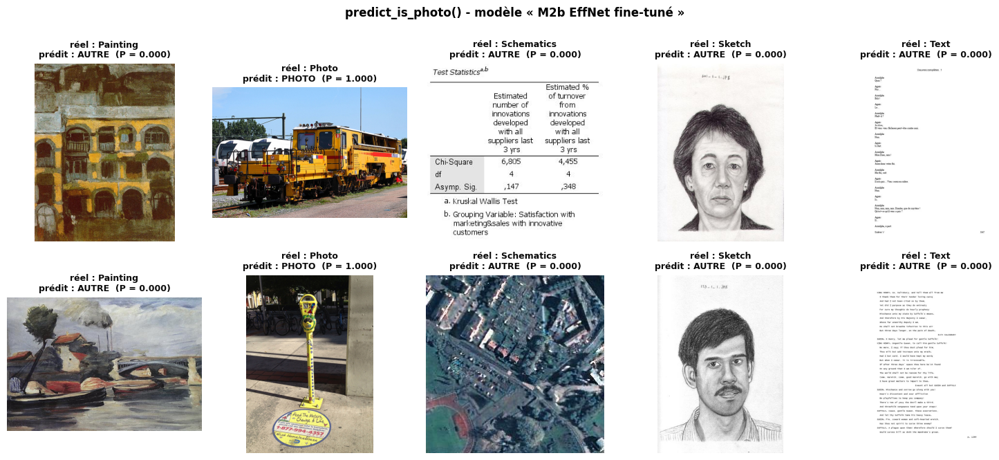

{'path': 'G:/projet_A5/data/livrable_1/Painting/painting_00779.jpg', 'is_photo': False, 'proba_photo': 1.5397556126117706e-05, 'label': 'autre', 'threshold': 0.5887, 'error': None}


In [38]:
# ============================================================================
# 12.4  Démonstration : predict_is_photo sur une image de chaque catégorie
# ============================================================================
demo = pd.concat([d.sample(2, random_state=SEED + 3) for _, d in test_df.groupby('category')])
fig, axes = plt.subplots(2, 5, figsize=(15, 6.6))
for ax, (_, r) in zip(axes.T.ravel(), demo.iterrows()):
    res = tpf.predict_is_photo(r['path'], config_path=CONFIG_PATH)
    img = iio.imread(r['path'])
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None); ax.axis('off')
    good = res['is_photo'] == bool(r['label'])
    ax.set_title(f"réel : {r['category']}\nprédit : {res['label'].upper()}  (P = {res['proba_photo']:.3f})",
                 fontsize=9, color='#0b0b0b' if good else '#e34948')
plt.suptitle(f'predict_is_photo() - modèle « {BEST} »', fontweight='bold', y=1.0); plt.tight_layout()
savefig('demo_predict_is_photo'); plt.show()
print(tpf.predict_is_photo(demo.iloc[0]['path'], config_path=CONFIG_PATH))

In [39]:
# ============================================================================
# 12.5  Démonstration sur un lot complet : predict_folder (répétition de la soutenance)
#       Le jour J, il suffit de faire pointer DEMO_DIR vers le dossier fourni.
# ============================================================================
DEMO_DIR = os.path.join(WORK_DIR, 'demo_lot')
if os.path.isdir(DEMO_DIR):
    shutil.rmtree(DEMO_DIR)
os.makedirs(DEMO_DIR)
lot = pd.concat([d.sample(40, random_state=SEED + 5) for _, d in test_df.groupby('category')])
for _, r in lot.iterrows():                                   # lot mélangé, sans information de catégorie dans l'arborescence
    shutil.copy(r['path'], os.path.join(DEMO_DIR, r['filename']))
shutil.copy(bad_file, os.path.join(DEMO_DIR, 'scan_corrompu.jpg'))

t0 = time.time()
lot_res = tpf.predict_folder(DEMO_DIR, config_path=CONFIG_PATH)
el = time.time() - t0
print(f'{len(lot_res)} fichiers traités en {el:.1f} s ({len(lot_res) / el:.0f} images/s, lecture disque comprise)')
display(lot_res.assign(path=lot_res['path'].map(os.path.basename)).head(8))
truth = lot.set_index('filename')['category']
lot_res['réel'] = lot_res['path'].map(lambda p: truth.get(os.path.basename(p), 'fichier invalide'))
print('Décision du filtre par catégorie réelle :')
display(pd.crosstab(lot_res['réel'], lot_res['label']))
lot_res.to_csv(os.path.join(WORK_DIR, 'demo_lot_predictions.csv'), index=False)

201 fichiers traités en 4.4 s (46 images/s, lecture disque comprise)


,path,proba_photo,is_photo,label,error
0,036_1_1_sz1.jpg,3.122684e-07,False,autre,None
1,045_1_1_sz1.jpg,4.441367e-06,False,autre,None
2,057_1_1_sz1.jpg,1.042216e-06,False,autre,None
3,066_1_1_sz1.jpg,1.109863e-06,False,autre,None
4,1008.png,6.454563e-09,False,autre,None
5,1009.png,6.380314e-09,False,autre,None
6,1031.png,3.653137e-10,False,autre,None
7,1040.png,4.337377e-07,False,autre,None


Décision du filtre par catégorie réelle :


label,autre,illisible,photo
réel,,,
Painting,39,0,1
Photo,1,0,39
Schematics,40,0,0
Sketch,40,0,0
Text,40,0,0
fichier invalide,0,1,0


**Lecture** : sur ce lot mélangé de 201 fichiers (40 images par catégorie et un fichier corrompu), le filtre traite **46 images par seconde**, lecture disque comprise, soit environ 36 minutes pour 100 000 images sur ce poste sans GPU.

- **198 images sur 200 sont correctement orientées** : une peinture est acceptée à tort, une photo est rejetée. Textes, schémas et croquis sont tous écartés.
- Le **fichier corrompu** est signalé (`label = illisible`, message dans la colonne `error`) **sans interrompre le traitement** du lot : c'est indispensable pour une chaîne automatisée.
- Le résultat est un `DataFrame`, enregistré en CSV : il s'intègre directement dans la suite du workflow (seules les lignes `is_photo == True` partent vers le débruitage et le captioning).

Pour la démonstration de soutenance, il suffit de faire pointer `DEMO_DIR` vers le dossier fourni et de relancer cette cellule.

<a id="13"></a>
## 13. Conclusion, recul critique et pistes d'amélioration

### 13.1 Synthèse des résultats

Le tableau ci-dessous est généré à partir des résultats calculés dans ce notebook (jeu de test, 6 039 images jamais vues pendant l'entraînement).

In [40]:
# ============================================================================
# 13.1  Tableau de synthèse (jeu de test)
# ============================================================================
TRAIN_COST = {'M0 Métadonnées': 'quelques secondes', 'M1 CNN scratch': f'{train_time_cnn / 60:.0f} min',
              'M2 EffNet gelé': f'10 min d\'extraction + {train_time_head:.0f} s',
              'M2b EffNet fine-tuné': f'{train_time_ft / 60:.0f} min (en plus de M2)'}
synth = pd.DataFrame({
    'accuracy': res_test['accuracy'].map('{:.1%}'.format),
    'précision': res_test['précision'].map('{:.3f}'.format),
    'rappel': res_test['rappel'].map('{:.3f}'.format),
    'F1 [IC 95 %]': [f"{res_test.loc[m, 'F1']:.3f} [{CI[m]['F1'][0]:.3f} ; {CI[m]['F1'][1]:.3f}]" for m in MODELS],
    'ROC-AUC': res_test['ROC-AUC'].map('{:.4f}'.format),
    'erreur Painting': [f"{err.loc['Painting', m]:.1f} %" for m in MODELS],
    'erreur Schematics': [f"{err.loc['Schematics', m]:.1f} %" for m in MODELS],
    'erreur Text + Sketch': [f"{(nerr.loc['Text', m] + nerr.loc['Sketch', m])} image(s)" for m in MODELS],
    'coût d\'entraînement (CPU)': [TRAIN_COST[m] for m in MODELS],
})
display(synth)
print(f'Modèle livré : {BEST} | seuil de décision = {THRESH[BEST]:.3f} | fichier : {os.path.join(MODEL_DIR, FINAL_MODEL_FILE)}')

,accuracy,précision,rappel,F1 [IC 95 %],ROC-AUC,erreur Painting,erreur Schematics,erreur Text + Sketch,coût d'entraînement (CPU)
M0 Métadonnées,99.2%,0.983,0.985,0.984 [0.979 ; 0.988],0.9991,1.7 %,0.1 %,0 image(s),quelques secondes
M1 CNN scratch,93.0%,0.859,0.859,0.859 [0.845 ; 0.872],0.9756,11.3 %,3.1 %,0 image(s),74 min
M2 EffNet gelé,98.4%,0.962,0.975,0.968 [0.961 ; 0.974],0.9982,3.2 %,0.8 %,0 image(s),10 min d'extraction + 28 s
M2b EffNet fine-tuné,98.9%,0.979,0.975,0.977 [0.972 ; 0.982],0.9988,1.7 %,0.4 %,0 image(s),38 min (en plus de M2)


Modèle livré : M2b EffNet fine-tuné | seuil de décision = 0.589 | fichier : G:/projet_A5\outputs_livrable1\models\photo_filter_model.keras


### 13.2 Réponse aux objectifs de TouNum

| Objectif du cahier des charges | Résultat | Statut |
|---|---|---|
| Distinguer une photo d'un **texte scanné** ou d'un **croquis** | 0 erreur sur 1 711 images de test, pour tous les modèles | ✅ atteint |
| Distinguer une photo d'un **schéma** | 5 schémas sur 1 330 (0,4 %) pris pour des photos par le modèle livré | ✅ atteint |
| Distinguer une photo d'une **peinture** (objectif idéal) | 26 peintures sur 1 499 (1,7 %) prises pour des photos ; ROC-AUC de 0,997 sur le sous-problème Photo vs Painting | ✅ atteint |
| Classification par **réseau de neurones**, avec TensorFlow / scikit-learn / Pandas / ImageIO | CNN from scratch, puis transfer learning EfficientNetB0 ; évaluation scikit-learn | ✅ |
| Solution **automatisée**, de la donnée à la décision | des archives ZIP à `predict_folder()`, sans étape manuelle | ✅ |
| Solution **maintenable et industrialisable** | configuration unique, module `tounum_photo_filter.py`, modèle et seuil décrits dans un fichier JSON, tests de cohérence | ✅ |

**Modèle livré : EfficientNetB0 fine-tuné** (M2b). Sur le jeu de test : accuracy de **98,9 %**, précision de **0,979** (sur 100 images envoyées au captioning, environ 98 sont de vraies photos), rappel de **0,975** (97,5 % des photos sont retenues), F1 de **0,977** avec un intervalle de confiance à 95 % de [0,972 ; 0,982].

### 13.3 Ce que la démarche a appris

1. **Le transfer learning est le bon choix pour ce problème.** Le CNN appris de zéro plafonne à 93 % après 74 minutes d'entraînement. Les caractéristiques pré-entraînées sur ImageNet donnent 98,4 % avec 28 secondes d'entraînement d'une petite tête, et 98,9 % après un fine-tuning partiel. Le gain du fine-tuning est statistiquement significatif (test de McNemar, p = 0,003).
2. **Le CNN maison suffit pour l'exigence minimale** (texte, croquis, schémas), mais pas pour les peintures : Grad-CAM montre qu'il s'appuie sur des indices de bas niveau (fond blanc, bords).
3. **L'accuracy seule aurait été trompeuse.** L'analyse par sous-catégorie, le zoom Photo vs Painting et l'examen visuel des erreurs racontent une histoire plus juste que le score global.

### 13.4 Recul critique : les limites à connaître

**1. Un biais de collecte dans les données (limite principale).** Le modèle 0, qui ne regarde que la taille et le poids des fichiers, atteint 99,2 % sur le jeu de test : il fait aussi bien que notre meilleur CNN (différence non significative, p = 0,07). Cela signifie que, dans ce jeu de données, les photos proviennent d'une source homogène (toutes de largeur ≤ 640 px), différente de celle des autres catégories. Nos CNN ne voient pas ces métadonnées, puisque toutes les images sont ramenées à la même taille. Mais ils pourraient exploiter des **indices indirects** de la même origine : niveau de netteté lié au facteur de réduction, artefacts de compression JPEG. **Nos scores mesurent donc la performance sur des images semblables à celles du jeu de données, pas nécessairement sur les numérisations réelles de TouNum.** Seule une évaluation sur un échantillon de vrais lots clients permettra de conclure. C'est la première action à mener avant une mise en production.

**2. Du bruit d'étiquetage.** Au moins 5 des 12 faux positifs les plus confiants sont en réalité des photographies rangées dans *Painting* ou *Schematics*. Les scores mesurés sont donc un peu pessimistes, et la notion de « photo » doit être précisée avec le client (photo d'une œuvre d'art ? capture d'écran ? photo fortement retouchée ?).

**3. Une sensibilité forte au bruit et au flou.** Le rappel du modèle livré tombe à 0,75 avec un bruit modéré et à 0,31 avec un bruit fort (§11.8). Or les numérisations de TouNum sont de qualité variable. Placé avant le débruitage, le filtre écarterait une partie des photos dégradées.

**4. Un CNN maison sous-entraîné.** Il est en sous-apprentissage : 12 epochs sur CPU, une résolution de 128 px, et un `ReduceLROnPlateau` trop réactif (patience de 1 epoch) qui a réduit le taux d'apprentissage dès la 2ᵉ epoch. Sa comparaison avec le transfer learning est donc un peu sévère pour lui.

**5. Un protocole d'évaluation à un seul découpage.** Un seul découpage train / validation / test et une seule graine aléatoire : les intervalles de confiance couvrent l'incertitude d'échantillonnage du test, mais pas la variabilité due à l'entraînement. Une validation croisée serait plus robuste, au prix d'un coût de calcul multiplié.

**6. Un seuil choisi pour maximiser le F1.** Ce critère traite les faux positifs et les faux négatifs à égalité. Si TouNum juge qu'une légende absurde coûte plus cher qu'une photo manquée, il faudra relever le seuil (plus de précision, moins de rappel). Le seuil se modifie dans `photo_filter_config.json`, sans réentraînement.

**7. Des probabilités non calibrées.** La sortie du modèle est utilisée comme un score ; sa calibration (une probabilité de 0,9 correspond-elle à 90 % de photos ?) n'a pas été vérifiée.

### 13.5 Pistes d'amélioration, par ordre de priorité

| Priorité | Action | Bénéfice attendu |
|---|---|---|
| 1 | **Évaluer sur de vrais lots numérisés par TouNum** (quelques centaines d'images étiquetées à la main) | Mesurer la performance réelle, hors du biais de collecte |
| 2 | **Revoir l'ordre du workflow** : débruitage (Livrable 2) avant le filtre, ou seconde passe sur les images rejetées | Ne pas perdre les photos dégradées |
| 3 | **Ajouter bruit, flou et compression à la data augmentation**, puis réentraîner | Filtre robuste par construction |
| 4 | **Nettoyer les étiquettes** avec l'aide du modèle (revue des désaccords confiants) | Données plus fiables, mesure plus juste |
| 5 | **Entraîner sur GPU** : plus d'epochs de fine-tuning (la perte baissait encore), résolution 224 px, dégel de plus de blocs | Gain de précision sur le cas Photo vs Painting |
| 6 | **Zone d'incertitude** : envoyer en contrôle manuel les images dont la probabilité est intermédiaire | Fiabilité accrue pour un coût humain faible |
| 7 | **Passer à une classification à 5 classes** (photo, peinture, schéma, croquis, texte) | Router chaque document vers le bon traitement (OCR pour les textes, par exemple) |
| 8 | **Surveiller en production** la distribution des scores et le taux de rejet par lot | Détecter une dérive des données entre clients |

### 13.6 Lien avec les livrables suivants

- **Livrable 2 (traitement d'images)** : le test de robustesse fournit un critère d'évaluation concret pour le débruitage. Un bon débruiteur doit faire remonter le rappel du filtre sur des photos dégradées.
- **Livrable 3 (captioning)** : le module `tounum_photo_filter.py` s'intègre en une ligne (`predict_is_photo(chemin)`). L'idée d'extraire une fois pour toutes des caractéristiques compactes avec un CNN pré-entraîné, validée ici (§10.4), est précisément celle de l'encodeur du modèle de captioning.

### 13.7 Messages clés pour la soutenance

1. Le filtre livré **répond aux deux niveaux d'exigence** : 0 erreur sur les textes et croquis, 1,7 % d'erreur sur les peintures.
2. Le **transfer learning** divise par 6 le nombre d'erreurs du CNN maison, pour un coût d'entraînement moindre.
3. Nous avons mis en évidence un **biais dans le jeu de données** (les métadonnées seules donnent 99 %) : les scores doivent être confirmés sur des données réelles de TouNum.
4. Le filtre est **sensible au bruit et au flou** : nous recommandons de placer le débruitage en amont.
5. La solution est **livrée sous forme utilisable** : un module Python, un modèle, un fichier de configuration, et un notebook reproductible de bout en bout.